In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **NEW**

In [ ]:
np.save(f"{BASE}/y_test.npy", np.asarray(y_test))

**Install/import and load saved files**

In [ ]:
!pip install shap joblib -q

import os
import json
import pickle
import joblib
import numpy as np
import pandas as pd
import shap

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts"

print("Files in artifact folder:")
for file in os.listdir(BASE_PATH):
    print(file, "-", round(os.path.getsize(os.path.join(BASE_PATH, file)) / (1024 * 1024), 2), "MB")


def smart_load_pkl(path):
    """
    Load .pkl file safely.
    First tries joblib, then pickle.
    """
    try:
        return joblib.load(path)
    except Exception as e1:
        print(f"joblib failed for {os.path.basename(path)}:", e1)
        try:
            with open(path, "rb") as f:
                return pickle.load(f)
        except Exception as e2:
            print(f"pickle also failed for {os.path.basename(path)}:", e2)
            raise


rf_model = smart_load_pkl(os.path.join(BASE_PATH, "rf_model.pkl"))
feature_names = smart_load_pkl(os.path.join(BASE_PATH, "feature_columns.pkl"))
label_encoder = smart_load_pkl(os.path.join(BASE_PATH, "label_encoder.pkl"))

X_train_sample = pd.read_csv(os.path.join(BASE_PATH, "X_train_sample.csv"))
X_test_sample = pd.read_csv(os.path.join(BASE_PATH, "X_test_sample.csv"))
y_test = np.load(os.path.join(BASE_PATH, "y_test.npy"), allow_pickle=True)

# Ensure correct column order
X_train_sample = X_train_sample[feature_names]
X_test_sample = X_test_sample[feature_names]

print("\nModel and files loaded successfully.")
print("Train sample:", X_train_sample.shape)
print("Test sample:", X_test_sample.shape)
print("Number of features:", len(feature_names))
print("Classes:", list(label_encoder.classes_))
print("Model type:", type(rf_model))
print("Label encoder type:", type(label_encoder))

Files in artifact folder:
rf_model.pkl - 48.98 MB
label_encoder.pkl - 0.0 MB
feature_columns.pkl - 0.0 MB
X_train_sample.csv - 107.24 MB
X_test_sample.csv - 26.86 MB
y_test.npy - 0.61 MB

Model and files loaded successfully.
Train sample: (320000, 78)
Test sample: (80000, 78)
Number of features: 78
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Label encoder type: <class 'sklearn.preprocessing._label.LabelEncoder'>


**Create SHAP explainer**

In [ ]:
background = X_train_sample.sample(
    n=min(100, len(X_train_sample)),
    random_state=42
)

explainer = shap.TreeExplainer(rf_model, background)

print("SHAP explainer created.")

SHAP explainer created.


**Build local evidence for one flow**

In [ ]:
def get_label_from_index(idx):
    return label_encoder.inverse_transform([idx])[0]


def extract_shap_for_predicted_class(shap_values, pred_idx):
    """
    Handles different SHAP output formats:
    1. list[class] -> array(samples, features)
    2. array(samples, features, classes)
    3. Explanation object
    """
    if isinstance(shap_values, list):
        return shap_values[pred_idx][0]

    if hasattr(shap_values, "values"):
        vals = shap_values.values
    else:
        vals = shap_values

    vals = np.array(vals)

    if vals.ndim == 3:
        return vals[0, :, pred_idx]
    elif vals.ndim == 2:
        return vals[0]
    else:
        raise ValueError(f"Unexpected SHAP values shape: {vals.shape}")


def build_local_evidence(row_id=0, top_k=5):
    x_row = X_test_sample.iloc[[row_id]]

    proba = rf_model.predict_proba(x_row)[0]
    pred_idx = int(np.argmax(proba))
    pred_label = get_label_from_index(pred_idx)
    confidence = float(proba[pred_idx])

    shap_values = explainer.shap_values(x_row)
    local_values = extract_shap_for_predicted_class(shap_values, pred_idx)

    top_idx = np.argsort(np.abs(local_values))[::-1][:top_k]

    local_features = []
    for idx in top_idx:
        shap_value = float(local_values[idx])
        feature_value = float(x_row.iloc[0, idx])

        local_features.append({
            "feature": feature_names[idx],
            "value": feature_value,
            "shap_value": shap_value,
            "effect": "supports predicted class" if shap_value > 0 else "opposes predicted class"
        })

    true_label = y_test[row_id]
    if isinstance(true_label, (np.integer, int)):
        true_label = get_label_from_index(int(true_label))

    return {
        "row_id": row_id,
        "true_label": str(true_label),
        "predicted_label": str(pred_label),
        "confidence": confidence,
        "local_explanation": local_features
    }


example = build_local_evidence(row_id=0, top_k=5)
print(json.dumps(example, indent=2))

{
  "row_id": 0,
  "true_label": "BENIGN",
  "predicted_label": "BENIGN",
  "confidence": 1.0,
  "local_explanation": [
    {
      "feature": "Destination Port",
      "value": 443.0,
      "shap_value": 0.014724666828895814,
      "effect": "supports predicted class"
    },
    {
      "feature": "Fwd Packet Length Max",
      "value": 1133.0,
      "shap_value": 0.014714537627566528,
      "effect": "supports predicted class"
    },
    {
      "feature": "Subflow Fwd Bytes",
      "value": 1523.0,
      "shap_value": 0.011565891287323575,
      "effect": "supports predicted class"
    },
    {
      "feature": "min_seg_size_forward",
      "value": 20.0,
      "shap_value": 0.011519951305192056,
      "effect": "supports predicted class"
    },
    {
      "feature": "Flow IAT Max",
      "value": 10000000.0,
      "shap_value": 0.0106089584052441,
      "effect": "supports predicted class"
    }
  ]
}


**Generate local evidence for 300 incidents**

In [ ]:
records = []

N = min(300, len(X_test_sample))

for row_id in range(N):
    evidence = build_local_evidence(row_id=row_id, top_k=5)

    records.append({
        "row_id": evidence["row_id"],
        "true_label": evidence["true_label"],
        "predicted_label": evidence["predicted_label"],
        "confidence": evidence["confidence"],
        "local_explanation_json": json.dumps(evidence["local_explanation"])
    })

local_evidence_df = pd.DataFrame(records)

output_path = os.path.join(BASE_PATH, "local_shap_evidence_300.csv")
local_evidence_df.to_csv(output_path, index=False)

print("Saved:", output_path)
local_evidence_df.head()

Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/local_shap_evidence_300.csv


,row_id,true_label,predicted_label,confidence,local_explanation_json
0,0,BENIGN,BENIGN,1.000000,"[{""feature"": ""Destination Port"", ""value"": 443...."
1,1,DoS Hulk,DoS Hulk,1.000000,"[{""feature"": ""Bwd Packet Length Std"", ""value"":..."
2,2,BENIGN,BENIGN,0.993333,"[{""feature"": ""Init_Win_bytes_backward"", ""value..."
3,3,BENIGN,BENIGN,1.000000,"[{""feature"": ""Total Length of Fwd Packets"", ""v..."
4,4,BENIGN,BENIGN,1.000000,"[{""feature"": ""PSH Flag Count"", ""value"": 0.0, ""..."


**Check the saved SHAP file**

In [ ]:
import os
import pandas as pd
import json

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts"

local_shap_path = os.path.join(BASE_PATH, "local_shap_evidence_300.csv")

local_shap_df = pd.read_csv(local_shap_path)

print(local_shap_df.shape)
local_shap_df.head()

(300, 5)


,row_id,true_label,predicted_label,confidence,local_explanation_json
0,0,BENIGN,BENIGN,1.000000,"[{""feature"": ""Destination Port"", ""value"": 443...."
1,1,DoS Hulk,DoS Hulk,1.000000,"[{""feature"": ""Bwd Packet Length Std"", ""value"":..."
2,2,BENIGN,BENIGN,0.993333,"[{""feature"": ""Init_Win_bytes_backward"", ""value..."
3,3,BENIGN,BENIGN,1.000000,"[{""feature"": ""Total Length of Fwd Packets"", ""v..."
4,4,BENIGN,BENIGN,1.000000,"[{""feature"": ""PSH Flag Count"", ""value"": 0.0, ""..."


**check one explanation**

In [ ]:
sample = local_shap_df.iloc[0]

print("Predicted label:", sample["predicted_label"])
print("Confidence:", sample["confidence"])

local_features = json.loads(sample["local_explanation_json"])
pd.DataFrame(local_features)

Predicted label: BENIGN
Confidence: 1.0


,feature,value,shap_value,effect
0,Destination Port,443.0,0.014725,supports predicted class
1,Fwd Packet Length Max,1133.0,0.014715,supports predicted class
2,Subflow Fwd Bytes,1523.0,0.011566,supports predicted class
3,min_seg_size_forward,20.0,0.011520,supports predicted class
4,Flow IAT Max,10000000.0,0.010609,supports predicted class


**Create updated evidence bundles**

In [ ]:
import numpy as np

def map_attack_stage(label):
    label = str(label)

    if label == "BENIGN":
        return "Normal"
    elif label == "PortScan":
        return "Reconnaissance"
    elif label in ["FTP-Patator", "SSH-Patator"]:
        return "Credential Access"
    elif label in ["Web Attack – Brute Force", "Web Attack – XSS", "Web Attack – SQL Injection",
                   "Web Attack - Brute Force", "Web Attack - XSS", "Web Attack - Sql Injection"]:
        return "Web Exploitation"
    elif label in ["DDoS", "DoS Hulk", "DoS GoldenEye", "DoS slowloris", "DoS Slowhttptest", "Heartbleed"]:
        return "Impact / Availability Attack"
    elif label == "Bot":
        return "Command and Control"
    elif label == "Infiltration":
        return "Advanced Intrusion"
    else:
        return "Unknown"


def base_severity(stage):
    severity_map = {
        "Normal": 0.0,
        "Reconnaissance": 3.0,
        "Credential Access": 6.0,
        "Web Exploitation": 6.5,
        "Command and Control": 8.0,
        "Impact / Availability Attack": 7.0,
        "Advanced Intrusion": 8.5,
        "Unknown": 2.0
    }
    return severity_map.get(stage, 2.0)


def compute_risk_score(stage, confidence, asset_criticality=1.0):
    score = base_severity(stage) * float(confidence) * asset_criticality
    return round(min(score, 10.0), 2)


def recommend_action(risk_score):
    if risk_score <= 2:
        return "Monitor"
    elif risk_score <= 5:
        return "Alert SOC Analyst"
    elif risk_score <= 7:
        return "Block Source IP"
    elif risk_score <= 8.5:
        return "Isolate Host"
    else:
        return "Isolate Host and Escalate Immediately"


local_shap_df["attack_stage"] = local_shap_df["predicted_label"].apply(map_attack_stage)
local_shap_df["risk_score"] = local_shap_df.apply(
    lambda row: compute_risk_score(row["attack_stage"], row["confidence"]),
    axis=1
)
local_shap_df["recommended_action"] = local_shap_df["risk_score"].apply(recommend_action)

local_shap_df.head()

,row_id,true_label,predicted_label,confidence,local_explanation_json,attack_stage,risk_score,recommended_action
0,0,BENIGN,BENIGN,1.000000,"[{""feature"": ""Destination Port"", ""value"": 443....",Normal,0.0,Monitor
1,1,DoS Hulk,DoS Hulk,1.000000,"[{""feature"": ""Bwd Packet Length Std"", ""value"":...",Impact / Availability Attack,7.0,Block Source IP
2,2,BENIGN,BENIGN,0.993333,"[{""feature"": ""Init_Win_bytes_backward"", ""value...",Normal,0.0,Monitor
3,3,BENIGN,BENIGN,1.000000,"[{""feature"": ""Total Length of Fwd Packets"", ""v...",Normal,0.0,Monitor
4,4,BENIGN,BENIGN,1.000000,"[{""feature"": ""PSH Flag Count"", ""value"": 0.0, ""...",Normal,0.0,Monitor


**Save the full evidence file**

In [ ]:
evidence_bundle_path = os.path.join(BASE_PATH, "instance_level_evidence_bundle_300.csv")
local_shap_df.to_csv(evidence_bundle_path, index=False)

print("Saved:", evidence_bundle_path)

Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/instance_level_evidence_bundle_300.csv


**Step 3 — Create LLM-ready prompts**

In [ ]:
def format_local_features(local_explanation_json):
    features = json.loads(local_explanation_json)

    lines = []
    for i, item in enumerate(features, start=1):
        lines.append(
            f"{i}. {item['feature']} = {item['value']:.4f}, "
            f"SHAP contribution = {item['shap_value']:.6f}, "
            f"effect = {item['effect']}"
        )

    return "\n".join(lines)


def build_llm_prompt(row):
    local_features_text = format_local_features(row["local_explanation_json"])

    prompt = f"""
You are a SOC analyst assistant. Generate an incident report using ONLY the evidence below.

Do not invent IP addresses, hostnames, malware names, users, tools, or attack details.
Do not mention any feature that is not listed in the local evidence.

Evidence:
Predicted IDS label: {row['predicted_label']}
Prediction confidence: {row['confidence']:.4f}
Mapped attack stage: {row['attack_stage']}
Risk score: {row['risk_score']}
Recommended action: {row['recommended_action']}

Instance-level local explanation:
{local_features_text}

Write the report using these headings:
1. Incident Summary
2. Recommended Response
3. Supporting Evidence
4. Risk Interpretation
5. Analyst Verification Steps
"""
    return prompt.strip()


local_shap_df["llm_prompt"] = local_shap_df.apply(build_llm_prompt, axis=1)

prompt_path = os.path.join(BASE_PATH, "instance_level_llm_prompts_300.csv")
local_shap_df.to_csv(prompt_path, index=False)

print("Saved:", prompt_path)
print(local_shap_df["llm_prompt"].iloc[0])

Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/instance_level_llm_prompts_300.csv
You are a SOC analyst assistant. Generate an incident report using ONLY the evidence below.

Do not invent IP addresses, hostnames, malware names, users, tools, or attack details.
Do not mention any feature that is not listed in the local evidence.

Evidence:
Predicted IDS label: BENIGN
Prediction confidence: 1.0000
Mapped attack stage: Normal
Risk score: 0.0
Recommended action: Monitor

Instance-level local explanation:
1. Destination Port = 443.0000, SHAP contribution = 0.014725, effect = supports predicted class
2. Fwd Packet Length Max = 1133.0000, SHAP contribution = 0.014715, effect = supports predicted class
3. Subflow Fwd Bytes = 1523.0000, SHAP contribution = 0.011566, effect = supports predicted class
4. min_seg_size_forward = 20.0000, SHAP contribution = 0.011520, effect = supports predicted class
5. Flow IAT Max = 10000000.0000, SHAP contribution = 0.010609, effec

**Install and load Qwen2.5-1.5B-Instruct**

In [ ]:
!pip install -q transformers accelerate sentencepiece pandas tqdm torch

import os
import gc
import torch
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts"

PROMPT_FILE = os.path.join(BASE_PATH, "instance_level_llm_prompts_300.csv")
OUTPUT_FILE = os.path.join(BASE_PATH, "instance_level_llm_reports_300.csv")

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("Prompt file:", PROMPT_FILE)
print("Output file:", OUTPUT_FILE)
print("CUDA available:", torch.cuda.is_available())

Prompt file: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/instance_level_llm_prompts_300.csv
Output file: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/instance_level_llm_reports_300.csv
CUDA available: True


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True
)

model.eval()

print("Model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully.


**Load the new instance-level SHAP prompts**

In [ ]:
df = pd.read_csv(PROMPT_FILE)

print("Loaded prompts:", df.shape)
print("Columns:", df.columns.tolist())

# Check that llm_prompt exists
assert "llm_prompt" in df.columns, "Column 'llm_prompt' not found. Please check your prompt generation step."

df.head()

Loaded prompts: (300, 9)
Columns: ['row_id', 'true_label', 'predicted_label', 'confidence', 'local_explanation_json', 'attack_stage', 'risk_score', 'recommended_action', 'llm_prompt']


,row_id,true_label,predicted_label,confidence,local_explanation_json,attack_stage,risk_score,recommended_action,llm_prompt
0,0,BENIGN,BENIGN,1.000000,"[{""feature"": ""Destination Port"", ""value"": 443....",Normal,0.0,Monitor,You are a SOC analyst assistant. Generate an i...
1,1,DoS Hulk,DoS Hulk,1.000000,"[{""feature"": ""Bwd Packet Length Std"", ""value"":...",Impact / Availability Attack,7.0,Block Source IP,You are a SOC analyst assistant. Generate an i...
2,2,BENIGN,BENIGN,0.993333,"[{""feature"": ""Init_Win_bytes_backward"", ""value...",Normal,0.0,Monitor,You are a SOC analyst assistant. Generate an i...
3,3,BENIGN,BENIGN,1.000000,"[{""feature"": ""Total Length of Fwd Packets"", ""v...",Normal,0.0,Monitor,You are a SOC analyst assistant. Generate an i...
4,4,BENIGN,BENIGN,1.000000,"[{""feature"": ""PSH Flag Count"", ""value"": 0.0, ""...",Normal,0.0,Monitor,You are a SOC analyst assistant. Generate an i...


**Define the LLM generation function**

In [ ]:
def generate_incident_report(prompt, max_new_tokens=420):
    """
    Generate one SOC incident report from an evidence-constrained prompt.
    """

    messages = [
        {
            "role": "system",
            "content": (
                "You are a careful SOC analyst assistant. "
                "Use only the supplied evidence. "
                "Do not invent IP addresses, hostnames, malware names, users, tools, or attack details."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id
        )

    # Remove the input prompt tokens from the output
    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]

    report = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return report

**Test generation on one incident first**

In [ ]:
test_prompt = df.loc[0, "llm_prompt"]

print("===== PROMPT SAMPLE =====")
print(test_prompt[:1500])

test_report = generate_incident_report(test_prompt)

print("\n===== GENERATED REPORT =====")
print(test_report)

===== PROMPT SAMPLE =====
You are a SOC analyst assistant. Generate an incident report using ONLY the evidence below.

Do not invent IP addresses, hostnames, malware names, users, tools, or attack details.
Do not mention any feature that is not listed in the local evidence.

Evidence:
Predicted IDS label: BENIGN
Prediction confidence: 1.0000
Mapped attack stage: Normal
Risk score: 0.0
Recommended action: Monitor

Instance-level local explanation:
1. Destination Port = 443.0000, SHAP contribution = 0.014725, effect = supports predicted class
2. Fwd Packet Length Max = 1133.0000, SHAP contribution = 0.014715, effect = supports predicted class
3. Subflow Fwd Bytes = 1523.0000, SHAP contribution = 0.011566, effect = supports predicted class
4. min_seg_size_forward = 20.0000, SHAP contribution = 0.011520, effect = supports predicted class
5. Flow IAT Max = 10000000.0000, SHAP contribution = 0.010609, effect = supports predicted class

Write the report using these headings:
1. Incident Summa

**Generate reports for all 300 incidents**

In [ ]:
# Resume support
if os.path.exists(OUTPUT_FILE):
    existing_df = pd.read_csv(OUTPUT_FILE)
    completed_ids = set(existing_df["row_id"].tolist())
    results = existing_df.to_dict("records")
    print(f"Resuming from existing file. Completed reports: {len(completed_ids)}")
else:
    completed_ids = set()
    results = []
    print("Starting new generation.")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    row_id = int(row["row_id"]) if "row_id" in df.columns else int(idx)

    if row_id in completed_ids:
        continue

    prompt = row["llm_prompt"]

    try:
        report = generate_incident_report(prompt)

        results.append({
            "row_id": row_id,
            "true_label": row.get("true_label", ""),
            "predicted_label": row.get("predicted_label", ""),
            "confidence": row.get("confidence", ""),
            "attack_stage": row.get("attack_stage", ""),
            "risk_score": row.get("risk_score", ""),
            "recommended_action": row.get("recommended_action", ""),
            "local_explanation_json": row.get("local_explanation_json", ""),
            "llm_prompt": prompt,
            "llm_report": report,
            "word_count": len(report.split())
        })

    except Exception as e:
        results.append({
            "row_id": row_id,
            "true_label": row.get("true_label", ""),
            "predicted_label": row.get("predicted_label", ""),
            "confidence": row.get("confidence", ""),
            "attack_stage": row.get("attack_stage", ""),
            "risk_score": row.get("risk_score", ""),
            "recommended_action": row.get("recommended_action", ""),
            "local_explanation_json": row.get("local_explanation_json", ""),
            "llm_prompt": prompt,
            "llm_report": "",
            "word_count": 0,
            "error": str(e)
        })

    # Save every 10 reports
    if len(results) % 10 == 0:
        temp_df = pd.DataFrame(results)
        temp_df.to_csv(OUTPUT_FILE, index=False)
        print(f"Saved progress: {len(results)} reports")

    # Clean GPU memory
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Final save
reports_df = pd.DataFrame(results)
reports_df = reports_df.sort_values("row_id").reset_index(drop=True)
reports_df.to_csv(OUTPUT_FILE, index=False)

print("Generation complete.")
print("Saved:", OUTPUT_FILE)
print("Total reports:", reports_df.shape)
reports_df.head()

Starting new generation.


  0%|          | 0/300 [00:00<?, ?it/s]

Saved progress: 10 reports
Saved progress: 20 reports
Saved progress: 30 reports
Saved progress: 40 reports
Saved progress: 50 reports
Saved progress: 60 reports
Saved progress: 70 reports
Saved progress: 80 reports
Saved progress: 90 reports
Saved progress: 100 reports
Saved progress: 110 reports
Saved progress: 120 reports
Saved progress: 130 reports
Saved progress: 140 reports
Saved progress: 150 reports
Saved progress: 160 reports
Saved progress: 170 reports
Saved progress: 180 reports
Saved progress: 190 reports
Saved progress: 200 reports
Saved progress: 210 reports
Saved progress: 220 reports
Saved progress: 230 reports
Saved progress: 240 reports
Saved progress: 250 reports
Saved progress: 260 reports
Saved progress: 270 reports
Saved progress: 280 reports
Saved progress: 290 reports
Saved progress: 300 reports
Generation complete.
Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/instance_level_llm_reports_300.csv
Total reports: (300, 11)


,row_id,true_label,predicted_label,confidence,attack_stage,risk_score,recommended_action,local_explanation_json,llm_prompt,llm_report,word_count
0,0,BENIGN,BENIGN,1.000000,Normal,0.0,Monitor,"[{""feature"": ""Destination Port"", ""value"": 443....",You are a SOC analyst assistant. Generate an i...,Incident Summary:\nThe incident involves a ben...,279
1,1,DoS Hulk,DoS Hulk,1.000000,Impact / Availability Attack,7.0,Block Source IP,"[{""feature"": ""Bwd Packet Length Std"", ""value"":...",You are a SOC analyst assistant. Generate an i...,### Incident Report\n\n#### Incident Summary\n...,283
2,2,BENIGN,BENIGN,0.993333,Normal,0.0,Monitor,"[{""feature"": ""Init_Win_bytes_backward"", ""value...",You are a SOC analyst assistant. Generate an i...,Incident Summary:\nThe incident summary indica...,291
3,3,BENIGN,BENIGN,1.000000,Normal,0.0,Monitor,"[{""feature"": ""Total Length of Fwd Packets"", ""v...",You are a SOC analyst assistant. Generate an i...,Incident Summary:\nThe incident involves a ben...,286
4,4,BENIGN,BENIGN,1.000000,Normal,0.0,Monitor,"[{""feature"": ""PSH Flag Count"", ""value"": 0.0, ""...",You are a SOC analyst assistant. Generate an i...,Incident Summary:\nThe incident summary provid...,339


**Quick quality check**

In [ ]:
reports_df = pd.read_csv(OUTPUT_FILE)

print("Total reports:", len(reports_df))
print("Average word count:", reports_df["word_count"].mean())
print("Median word count:", reports_df["word_count"].median())

reports_df[[
    "row_id",
    "true_label",
    "predicted_label",
    "confidence",
    "attack_stage",
    "risk_score",
    "recommended_action",
    "word_count"
]].head()

Total reports: 300
Average word count: 269.1066666666667
Median word count: 262.5


,row_id,true_label,predicted_label,confidence,attack_stage,risk_score,recommended_action,word_count
0,0,BENIGN,BENIGN,1.000000,Normal,0.0,Monitor,279
1,1,DoS Hulk,DoS Hulk,1.000000,Impact / Availability Attack,7.0,Block Source IP,283
2,2,BENIGN,BENIGN,0.993333,Normal,0.0,Monitor,291
3,3,BENIGN,BENIGN,1.000000,Normal,0.0,Monitor,286
4,4,BENIGN,BENIGN,1.000000,Normal,0.0,Monitor,339


**View one regenerated report**

In [ ]:
sample_id = 0

print("Predicted label:", reports_df.loc[sample_id, "predicted_label"])
print("Attack stage:", reports_df.loc[sample_id, "attack_stage"])
print("Risk score:", reports_df.loc[sample_id, "risk_score"])
print("Recommended action:", reports_df.loc[sample_id, "recommended_action"])

print("\n===== LOCAL SHAP EVIDENCE =====")
print(reports_df.loc[sample_id, "local_explanation_json"])

print("\n===== GENERATED LLM REPORT =====")
print(reports_df.loc[sample_id, "llm_report"])

Predicted label: BENIGN
Attack stage: Normal
Risk score: 0.0
Recommended action: Monitor

===== LOCAL SHAP EVIDENCE =====
[{"feature": "Destination Port", "value": 443.0, "shap_value": 0.014724666828895814, "effect": "supports predicted class"}, {"feature": "Fwd Packet Length Max", "value": 1133.0, "shap_value": 0.014714537627566528, "effect": "supports predicted class"}, {"feature": "Subflow Fwd Bytes", "value": 1523.0, "shap_value": 0.011565891287323575, "effect": "supports predicted class"}, {"feature": "min_seg_size_forward", "value": 20.0, "shap_value": 0.011519951305192056, "effect": "supports predicted class"}, {"feature": "Flow IAT Max", "value": 10000000.0, "shap_value": 0.0106089584052441, "effect": "supports predicted class"}]

===== GENERATED LLM REPORT =====
Incident Summary:
The incident involves a benign network traffic pattern with no suspicious activity detected by the Intrusion Detection System (IDS). The traffic is normal and does not indicate any malicious intent.



# **Continue from old**

In [ ]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE")

csv_files = sorted(DATA_DIR.rglob("*.csv"))

print("Total CSV files found:", len(csv_files))
for f in csv_files:
    print(f)

Total CSV files found: 8
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv


# **Load and clean dataset**

In [ ]:
import pandas as pd
import numpy as np

def clean_columns(df):
    df.columns = df.columns.str.strip()
    return df

dfs = []

for file in csv_files:
    print("Loading:", file.name)
    temp = pd.read_csv(file, low_memory=False)
    temp = clean_columns(temp)

    # Sample max 50,000 rows per file for first baseline
    if len(temp) > 50000:
        temp = temp.sample(n=50000, random_state=42)

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Dataset shape:", df.shape)
print(df["Label"].value_counts())

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Dataset shape: (400000, 79)
Label
BENIGN                        322964
DDoS                           28503
PortScan                       27694
DoS Hulk                       16591
FTP-Patator                      894
DoS GoldenEye                    718
SSH-Patator                      666
Bot                              494
Web Attack � Brute Force         449
DoS Slowhttptest                 412
DoS slowloris                    405
Web Attack � XSS                 196
Web Attack � Sql Injection         7
Infiltration                       5
Heartbleed 

# **Basic preprocessing**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Clean column names
df.columns = df.columns.str.strip()

# Clean label
df["Label"] = df["Label"].astype(str).str.strip()

# Separate X and y
X = df.drop(columns=["Label"])
y = df["Label"]

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Drop columns that are fully NaN
X = X.dropna(axis=1, how="all")

# Fill remaining NaN values with column median
X = X.fillna(X.median())

# Clip extremely large values to avoid float overflow
lower = X.quantile(0.001)
upper = X.quantile(0.999)
X = X.clip(lower=lower, upper=upper, axis=1)

# Final safety check
print("Any NaN:", X.isna().sum().sum())
print("Any infinity:", np.isinf(X.values).sum())
print("Shape after cleaning:", X.shape)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Any NaN: 0
Any infinity: 0
Shape after cleaning: (400000, 78)
Classes:
0 = BENIGN
1 = Bot
2 = DDoS
3 = DoS GoldenEye
4 = DoS Hulk
5 = DoS Slowhttptest
6 = DoS slowloris
7 = FTP-Patator
8 = Heartbleed
9 = Infiltration
10 = PortScan
11 = SSH-Patator
12 = Web Attack � Brute Force
13 = Web Attack � Sql Injection
14 = Web Attack � XSS
Train: (320000, 78)
Test: (80000, 78)


# **Prepare features and labels**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Force classification_report to include all encoded classes
all_labels = np.arange(len(label_encoder.classes_))

print(
    classification_report(
        y_test,
        y_pred,
        labels=all_labels,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Accuracy: 0.995225
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     64593
                       Bot       0.31      0.93      0.46        99
                      DDoS       1.00      1.00      1.00      5701
             DoS GoldenEye       0.99      0.95      0.97       144
                  DoS Hulk       0.99      1.00      0.99      3318
          DoS Slowhttptest       0.96      0.98      0.97        82
             DoS slowloris       0.99      0.99      0.99        81
               FTP-Patator       1.00      0.99      1.00       179
                Heartbleed       0.00      0.00      0.00         0
              Infiltration       0.00      0.00      0.00         1
                  PortScan       0.99      1.00      1.00      5539
               SSH-Patator       1.00      0.98      0.99       133
  Web Attack � Brute Force       0.73      0.71      0.72        90
Web Attack � Sql Injection  

Opt: Missing Class

In [ ]:
present_classes = set(np.unique(y_test)) | set(np.unique(y_pred))
all_classes = set(range(len(label_encoder.classes_)))

missing_classes = all_classes - present_classes

print("Missing class IDs:", missing_classes)

for cls_id in missing_classes:
    print("Missing class name:", label_encoder.classes_[cls_id])

Missing class IDs: {8}
Missing class name: Heartbleed


# **Train first baseline model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

all_labels = np.arange(len(label_encoder.classes_))

print(
    classification_report(
        y_test,
        y_pred,
        labels=all_labels,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Accuracy: 0.995225
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     64593
                       Bot       0.31      0.93      0.46        99
                      DDoS       1.00      1.00      1.00      5701
             DoS GoldenEye       0.99      0.95      0.97       144
                  DoS Hulk       0.99      1.00      0.99      3318
          DoS Slowhttptest       0.96      0.98      0.97        82
             DoS slowloris       0.99      0.99      0.99        81
               FTP-Patator       1.00      0.99      1.00       179
                Heartbleed       0.00      0.00      0.00         0
              Infiltration       0.00      0.00      0.00         1
                  PortScan       0.99      1.00      1.00      5539
               SSH-Patator       1.00      0.98      0.99       133
  Web Attack � Brute Force       0.73      0.71      0.72        90
Web Attack � Sql Injection  

# **Add attack-stage mapping**

In [ ]:
def map_attack_stage(label):
    label = label.lower()

    if "benign" in label:
        return "Normal"
    elif "portscan" in label:
        return "Reconnaissance"
    elif "ftp" in label or "ssh" in label or "patator" in label:
        return "Credential Access"
    elif "web attack" in label or "xss" in label or "sql" in label or "brute force" in label:
        return "Web Exploitation"
    elif "dos" in label or "ddos" in label:
        return "Impact / Availability Attack"
    elif "bot" in label:
        return "Command and Control"
    elif "infiltration" in label:
        return "Advanced Intrusion"
    elif "heartbleed" in label:
        return "Exploitation / Credential Risk"
    else:
        return "Unknown"

# **Add risk-aware response policy**

In [ ]:
def severity_score(label):
    label = label.lower()

    if "benign" in label:
        return 0
    elif "portscan" in label:
        return 4
    elif "ftp" in label or "ssh" in label:
        return 5
    elif "web attack" in label:
        return 6
    elif "dos" in label:
        return 7
    elif "ddos" in label:
        return 8
    elif "bot" in label:
        return 8
    elif "infiltration" in label:
        return 9
    elif "heartbleed" in label:
        return 9
    else:
        return 5


def recommend_action(label, confidence, asset_criticality=0.8):
    severity = severity_score(label)
    risk = severity * confidence * asset_criticality

    if risk <= 2:
        action = "Monitor"
    elif risk <= 5:
        action = "Alert SOC Analyst"
    elif risk <= 7:
        action = "Block Source IP"
    elif risk <= 8.5:
        action = "Isolate Host"
    else:
        action = "Isolate Host and Escalate Immediately"

    return round(risk, 2), action

# **Extract feature evidence**

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
0,Destination Port,0.068590
67,Init_Win_bytes_backward,0.055010
16,Flow IAT Mean,0.026613
37,Bwd Packets/s,0.026438
15,Flow Packets/s,0.026169
69,min_seg_size_forward,0.025641
18,Flow IAT Max,0.025028
6,Fwd Packet Length Max,0.024120
17,Flow IAT Std,0.023535
66,Init_Win_bytes_forward,0.023482


For each prediction

In [ ]:
top_features = feature_importance.head(5)["feature"].tolist()
top_features

['Destination Port',
 'Init_Win_bytes_backward',
 'Flow IAT Mean',
 'Bwd Packets/s',
 'Flow Packets/s']

# **Create baseline SOC explanation**

In [ ]:
def generate_template_explanation(evidence):
    explanation = f"""
Incident Summary:
The event was classified as {evidence['predicted_label']} with a confidence score of {evidence['prediction_confidence']}.

Attack Stage:
This event is mapped to the {evidence['attack_stage']} stage.

Recommended Response:
The recommended action is: {evidence['recommended_action']}.

Reasoning:
The risk score is {evidence['risk_score']}, which indicates the expected severity of the event based on the predicted attack type, model confidence, and assumed asset criticality.

Supporting Evidence:
The most important features influencing the decision were:
{', '.join(evidence['top_xai_features'])}.

SOC Analyst Note:
The analyst should verify whether the affected host shows additional suspicious activity and confirm whether containment is necessary.
"""
    return explanation

print(generate_template_explanation(evidence_json))


Incident Summary:
The event was classified as DoS Hulk with a confidence score of 1.0.

Attack Stage:
This event is mapped to the Impact / Availability Attack stage.

Recommended Response:
The recommended action is: Block Source IP.

Reasoning:
The risk score is 5.6, which indicates the expected severity of the event based on the predicted attack type, model confidence, and assumed asset criticality.

Supporting Evidence:
The most important features influencing the decision were:
Destination Port, Init_Win_bytes_backward, Flow IAT Mean, Bwd Packets/s, Flow Packets/s.

SOC Analyst Note:
The analyst should verify whether the affected host shows additional suspicious activity and confirm whether containment is necessary.



# **Generate structured evidence JSON**

In [ ]:
import json

# Select one malicious sample from the test set
test_df = X_test.copy()
test_df["true_label_id"] = y_test
test_df["true_label"] = label_encoder.inverse_transform(y_test)

malicious_samples = test_df[test_df["true_label"] != "BENIGN"]

idx = malicious_samples.index[0]

# Important: use loc, not iloc
sample = X_test.loc[[idx]]

pred_class = rf_model.predict(sample)[0]
pred_label = label_encoder.inverse_transform([pred_class])[0]

pred_proba = rf_model.predict_proba(sample)[0]
confidence = float(np.max(pred_proba))

attack_stage = map_attack_stage(pred_label)
risk_score, action = recommend_action(pred_label, confidence)

evidence_json = {
    "event_id": "CICIDS2017-EVENT-MAL-0001",
    "source_dataset": "CIC-IDS2017",
    "true_label": malicious_samples.loc[idx, "true_label"],
    "predicted_label": pred_label,
    "attack_stage": attack_stage,
    "prediction_confidence": round(confidence, 4),
    "risk_score": risk_score,
    "recommended_action": action,
    "top_xai_features": top_features,
    "evidence_summary": [
        f"The model classified the event as {pred_label}.",
        f"The attack stage is mapped as {attack_stage}.",
        f"The prediction confidence is {round(confidence, 4)}.",
        f"The calculated risk score is {risk_score}.",
        f"The most influential features include {', '.join(top_features)}."
    ]
}

print(json.dumps(evidence_json, indent=4))
print(generate_template_explanation(evidence_json))

{
    "event_id": "CICIDS2017-EVENT-MAL-0001",
    "source_dataset": "CIC-IDS2017",
    "true_label": "DoS Hulk",
    "predicted_label": "DoS Hulk",
    "attack_stage": "Impact / Availability Attack",
    "prediction_confidence": 1.0,
    "risk_score": 5.6,
    "recommended_action": "Block Source IP",
    "top_xai_features": [
        "Destination Port",
        "Init_Win_bytes_backward",
        "Flow IAT Mean",
        "Bwd Packets/s",
        "Flow Packets/s"
    ],
    "evidence_summary": [
        "The model classified the event as DoS Hulk.",
        "The attack stage is mapped as Impact / Availability Attack.",
        "The prediction confidence is 1.0.",
        "The calculated risk score is 5.6.",
        "The most influential features include Destination Port, Init_Win_bytes_backward, Flow IAT Mean, Bwd Packets/s, Flow Packets/s."
    ]
}

Incident Summary:
The event was classified as DoS Hulk with a confidence score of 1.0.

Attack Stage:
This event is mapped to the Impact /

# **Train attack-stage classification baseline**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Create attack-stage labels from original CIC-IDS2017 labels
df["Attack_Stage"] = df["Label"].apply(map_attack_stage)

print("Attack-stage distribution:")
print(df["Attack_Stage"].value_counts())

# Use the already-cleaned feature matrix X
y_stage = df["Attack_Stage"]

stage_encoder = LabelEncoder()
y_stage_encoded = stage_encoder.fit_transform(y_stage)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y_stage_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_stage_encoded
)

stage_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

stage_model.fit(X_train_s, y_train_s)

y_pred_s = stage_model.predict(X_test_s)

print("Attack-Stage Accuracy:", accuracy_score(y_test_s, y_pred_s))

all_stage_labels = np.arange(len(stage_encoder.classes_))

print(
    classification_report(
        y_test_s,
        y_pred_s,
        labels=all_stage_labels,
        target_names=stage_encoder.classes_,
        zero_division=0
    )
)

Attack-stage distribution:
Attack_Stage
Normal                            322964
Impact / Availability Attack       46629
Reconnaissance                     27694
Credential Access                   1560
Web Exploitation                     652
Command and Control                  494
Advanced Intrusion                     5
Exploitation / Credential Risk         2
Name: count, dtype: int64
Attack-Stage Accuracy: 0.9967875
                                precision    recall  f1-score   support

            Advanced Intrusion       0.00      0.00      0.00         1
           Command and Control       0.35      0.91      0.51        99
             Credential Access       1.00      1.00      1.00       312
Exploitation / Credential Risk       0.00      0.00      0.00         0
  Impact / Availability Attack       1.00      1.00      1.00      9326
                        Normal       1.00      1.00      1.00     64593
                Reconnaissance       0.99      1.00      1.00      5

# **Generate bulk evidence and explanation dataset**

In [ ]:
import json
import pandas as pd
import numpy as np

# Recreate test results dataframe
test_results = X_test.copy()
test_results["true_label_id"] = y_test
test_results["true_label"] = label_encoder.inverse_transform(y_test)
test_results["pred_label_id"] = y_pred
test_results["predicted_label"] = label_encoder.inverse_transform(y_pred)

# Take a balanced-ish sample:
# 200 benign + 300 attack samples, if available
benign_pool = test_results[test_results["true_label"] == "BENIGN"]
attack_pool = test_results[test_results["true_label"] != "BENIGN"]

benign_sample = benign_pool.sample(
    n=min(200, len(benign_pool)),
    random_state=42
)

attack_sample = attack_pool.sample(
    n=min(300, len(attack_pool)),
    random_state=42
)

evidence_source = pd.concat([benign_sample, attack_sample]).sample(
    frac=1,
    random_state=42
)

print("Evidence samples selected:", evidence_source.shape)
print(evidence_source["true_label"].value_counts())

Evidence samples selected: (500, 82)
true_label
BENIGN                      200
DDoS                        128
PortScan                     92
DoS Hulk                     67
Bot                           3
DoS slowloris                 3
Web Attack � Brute Force      3
FTP-Patator                   2
SSH-Patator                   1
DoS GoldenEye                 1
Name: count, dtype: int64


In [ ]:
evidence_rows = []

for count, idx in enumerate(evidence_source.index, start=1):
    sample = X_test.loc[[idx]]

    pred_class = rf_model.predict(sample)[0]
    pred_label = label_encoder.inverse_transform([pred_class])[0]

    pred_proba = rf_model.predict_proba(sample)[0]
    confidence = float(np.max(pred_proba))

    attack_stage = map_attack_stage(pred_label)
    risk_score, action = recommend_action(pred_label, confidence)

    evidence = {
        "event_id": f"CICIDS2017-EVENT-{count:05d}",
        "source_dataset": "CIC-IDS2017",
        "true_label": evidence_source.loc[idx, "true_label"],
        "predicted_label": pred_label,
        "attack_stage": attack_stage,
        "prediction_confidence": round(confidence, 4),
        "risk_score": risk_score,
        "recommended_action": action,
        "top_xai_features": top_features,
        "evidence_summary": [
            f"The model classified the event as {pred_label}.",
            f"The attack stage is mapped as {attack_stage}.",
            f"The prediction confidence is {round(confidence, 4)}.",
            f"The calculated risk score is {risk_score}.",
            f"The most influential features include {', '.join(top_features)}."
        ]
    }

    template_explanation = generate_template_explanation(evidence)

    evidence_rows.append({
        "event_id": evidence["event_id"],
        "source_dataset": evidence["source_dataset"],
        "true_label": evidence["true_label"],
        "predicted_label": evidence["predicted_label"],
        "attack_stage": evidence["attack_stage"],
        "prediction_confidence": evidence["prediction_confidence"],
        "risk_score": evidence["risk_score"],
        "recommended_action": evidence["recommended_action"],
        "top_xai_features": json.dumps(evidence["top_xai_features"]),
        "evidence_json": json.dumps(evidence),
        "template_explanation": template_explanation
    })

evidence_df = pd.DataFrame(evidence_rows)

print("Evidence dataset shape:", evidence_df.shape)
evidence_df.head()

Evidence dataset shape: (500, 11)


,event_id,source_dataset,true_label,predicted_label,attack_stage,prediction_confidence,risk_score,recommended_action,top_xai_features,evidence_json,template_explanation
0,CICIDS2017-EVENT-00001,CIC-IDS2017,PortScan,PortScan,Reconnaissance,1.0000,3.20,Alert SOC Analyst,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00001"", ""source...",\nIncident Summary:\nThe event was classified ...
1,CICIDS2017-EVENT-00002,CIC-IDS2017,BENIGN,BENIGN,Normal,1.0000,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00002"", ""source...",\nIncident Summary:\nThe event was classified ...
2,CICIDS2017-EVENT-00003,CIC-IDS2017,DoS Hulk,DoS Hulk,Impact / Availability Attack,0.9944,5.57,Block Source IP,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00003"", ""source...",\nIncident Summary:\nThe event was classified ...
3,CICIDS2017-EVENT-00004,CIC-IDS2017,BENIGN,BENIGN,Normal,1.0000,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00004"", ""source...",\nIncident Summary:\nThe event was classified ...
4,CICIDS2017-EVENT-00005,CIC-IDS2017,BENIGN,BENIGN,Normal,0.8977,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00005"", ""source...",\nIncident Summary:\nThe event was classified ...


# **Saving Evidence Dataset**

In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

evidence_path = f"{OUTPUT_DIR}/xir_llm_evidence_dataset.csv"
evidence_df.to_csv(evidence_path, index=False)

print("Saved evidence dataset to:")
print(evidence_path)

Saved evidence dataset to:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/xir_llm_evidence_dataset.csv


# **Create evidence-constrained LLM prompts**

In [ ]:
def build_evidence_constrained_prompt(evidence_json_text):
    prompt = f"""
You are a SOC analyst assistant.

Your task is to explain an incident-response decision using only the provided evidence.

Rules:
1. Use only the evidence provided in the JSON.
2. Do not invent IP addresses, malware names, users, hosts, tools, or attack details.
3. Explain the decision clearly for a human SOC analyst.
4. Mention the attack stage, risk score, recommended action, and supporting evidence.
5. Keep the explanation concise and operationally useful.

Evidence JSON:
{evidence_json_text}

Write the explanation in this structure:

Incident Summary:
Recommended Response:
Supporting Evidence:
Risk Interpretation:
Analyst Verification Steps:
"""
    return prompt


# Create prompt for first event
sample_prompt = build_evidence_constrained_prompt(evidence_df.iloc[0]["evidence_json"])

print(sample_prompt)


You are a SOC analyst assistant.

Your task is to explain an incident-response decision using only the provided evidence.

Rules:
1. Use only the evidence provided in the JSON.
2. Do not invent IP addresses, malware names, users, hosts, tools, or attack details.
3. Explain the decision clearly for a human SOC analyst.
4. Mention the attack stage, risk score, recommended action, and supporting evidence.
5. Keep the explanation concise and operationally useful.

Evidence JSON:
{"event_id": "CICIDS2017-EVENT-00001", "source_dataset": "CIC-IDS2017", "true_label": "PortScan", "predicted_label": "PortScan", "attack_stage": "Reconnaissance", "prediction_confidence": 1.0, "risk_score": 3.2, "recommended_action": "Alert SOC Analyst", "top_xai_features": ["Destination Port", "Init_Win_bytes_backward", "Flow IAT Mean", "Bwd Packets/s", "Flow Packets/s"], "evidence_summary": ["The model classified the event as PortScan.", "The attack stage is mapped as Reconnaissance.", "The prediction confidence

# **Create Columns for LLM Output**

In [ ]:
evidence_df["llm_prompt"] = evidence_df["evidence_json"].apply(build_evidence_constrained_prompt)
evidence_df["llm_explanation"] = ""

prompt_path = f"{OUTPUT_DIR}/xir_llm_prompts_ready.csv"
evidence_df.to_csv(prompt_path, index=False)

print("Saved prompt-ready dataset:")
print(prompt_path)

Saved prompt-ready dataset:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/xir_llm_prompts_ready.csv


# **Add Simple Explanation Evaluation**

In [ ]:
def evaluate_explanation(row, explanation_col="template_explanation"):
    explanation = str(row[explanation_col]).lower()

    stage_covered = str(row["attack_stage"]).lower() in explanation
    action_covered = str(row["recommended_action"]).lower() in explanation
    risk_covered = str(row["risk_score"]) in explanation or "risk" in explanation
    label_covered = str(row["predicted_label"]).lower() in explanation

    features = json.loads(row["top_xai_features"])
    feature_hits = sum(1 for f in features if f.lower() in explanation)
    feature_coverage = feature_hits / len(features) if features else 0

    completeness_score = np.mean([
        stage_covered,
        action_covered,
        risk_covered,
        label_covered,
        feature_coverage
    ])

    return pd.Series({
        "stage_covered": int(stage_covered),
        "action_covered": int(action_covered),
        "risk_covered": int(risk_covered),
        "label_covered": int(label_covered),
        "feature_coverage": round(feature_coverage, 3),
        "completeness_score": round(completeness_score, 3),
        "word_count": len(str(row[explanation_col]).split())
    })


template_eval = evidence_df.apply(evaluate_explanation, axis=1)

template_eval.head()

,stage_covered,action_covered,risk_covered,label_covered,feature_coverage,completeness_score,word_count
0,1.0,1.0,1.0,1.0,1.0,1.0,100.0
1,1.0,1.0,1.0,1.0,1.0,1.0,98.0
2,1.0,1.0,1.0,1.0,1.0,1.0,104.0
3,1.0,1.0,1.0,1.0,1.0,1.0,98.0
4,1.0,1.0,1.0,1.0,1.0,1.0,98.0


Summarize

In [ ]:
print("Template Explanation Evaluation:")
print(template_eval.mean(numeric_only=True))

Template Explanation Evaluation:
stage_covered           1.000
action_covered          1.000
risk_covered            1.000
label_covered           1.000
feature_coverage        1.000
completeness_score      1.000
word_count            100.584
dtype: float64


# **Add LLM Explanation Generation**

In [ ]:
!pip install -q transformers accelerate sentencepiece
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm

model_id = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

def generate_llm_explanation(prompt, max_new_tokens=300):
    messages = [
        {
            "role": "system",
            "content": "You are a concise SOC analyst assistant. Use only the provided evidence."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return response.strip()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

# **Generate LLM explanations**

In [ ]:
N = 300  # Start small for Colab

for i in tqdm(range(N)):
    prompt = evidence_df.loc[i, "llm_prompt"]
    evidence_df.loc[i, "llm_explanation"] = generate_llm_explanation(prompt)

evidence_df[["event_id", "predicted_label", "recommended_action", "llm_explanation"]].head()

100%|██████████| 300/300 [1:03:04<00:00, 12.61s/it]


,event_id,predicted_label,recommended_action,llm_explanation
0,CICIDS2017-EVENT-00001,PortScan,Alert SOC Analyst,**Incident Summary:**\nAn event was detected w...
1,CICIDS2017-EVENT-00002,BENIGN,Monitor,**Incident Summary:**\nAn event was identified...
2,CICIDS2017-EVENT-00003,DoS Hulk,Block Source IP,**Incident Summary:**\nAn incident was detecte...
3,CICIDS2017-EVENT-00004,BENIGN,Monitor,**Incident Summary:**\nAn event was identified...
4,CICIDS2017-EVENT-00005,BENIGN,Monitor,**Incident Summary:**\nAn event was identified...


# **Save**

In [ ]:
llm_output_path = f"{OUTPUT_DIR}/xir_llm_explanations_300.csv"
evidence_df.head(N).to_csv(llm_output_path, index=False)

print("Saved LLM explanations to:")
print(llm_output_path)

Saved LLM explanations to:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/xir_llm_explanations_300.csv


# **Evaluate LLM Explanations**

In [ ]:
llm_eval = evidence_df.head(N).apply(
    lambda row: evaluate_explanation(row, explanation_col="llm_explanation"),
    axis=1
)

print("LLM Explanation Evaluation:")
print(llm_eval.mean(numeric_only=True))

LLM Explanation Evaluation:
stage_covered           0.613333
action_covered          0.436667
risk_covered            1.000000
label_covered           0.990000
feature_coverage        0.810667
completeness_score      0.770133
word_count            204.953333
dtype: float64


# **Compare template vs LLM**

In [ ]:
template_eval_50 = template_eval.head(N)

comparison = pd.DataFrame({
    "metric": template_eval_50.mean(numeric_only=True).index,
    "template": template_eval_50.mean(numeric_only=True).values,
    "llm": llm_eval.mean(numeric_only=True).values
})

comparison

,metric,template,llm
0,stage_covered,1.000000,0.613333
1,action_covered,1.000000,0.436667
2,risk_covered,1.000000,1.000000
3,label_covered,1.000000,0.990000
4,feature_coverage,1.000000,0.810667
5,completeness_score,1.000000,0.770133
6,word_count,100.526667,204.953333


# **Save comparison**

In [ ]:
comparison_path = f"{OUTPUT_DIR}/template_vs_llm_explanation_comparison.csv"
comparison.to_csv(comparison_path, index=False)

print("Saved comparison:")
print(comparison_path)

Saved comparison:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/template_vs_llm_explanation_comparison.csv


# **Hallucination Analysis**

In [ ]:
import re

unsupported_terms = [
    "ransomware",
    "mimikatz",
    "cobalt strike",
    "trojan",
    "worm",
    "phishing",
    "database server",
    "domain controller",
    "payroll",
    "finance server",
    "malware family",
    "APT29",
    "Lazarus"
]

def detect_hallucination(row, explanation_col="llm_explanation"):
    explanation = str(row[explanation_col]).lower()
    evidence_text = str(row["evidence_json"]).lower()

    unsupported_hits = []

    for term in unsupported_terms:
        if term in explanation and term not in evidence_text:
            unsupported_hits.append(term)

    # Detect invented IP addresses
    ip_pattern = r"\b(?:\d{1,3}\.){3}\d{1,3}\b"
    ips = re.findall(ip_pattern, explanation)

    if len(ips) > 0:
        unsupported_hits.extend(ips)

    return pd.Series({
        "hallucination_flag": int(len(unsupported_hits) > 0),
        "unsupported_terms": ", ".join(unsupported_hits)
    })


hallucination_eval = evidence_df.head(N).apply(detect_hallucination, axis=1)

print("Hallucination rate:")
print(hallucination_eval["hallucination_flag"].mean())

hallucination_eval.head()

Hallucination rate:
0.0


,hallucination_flag,unsupported_terms
0,0,
1,0,
2,0,
3,0,
4,0,


In [ ]:
N = 300

hallucination_report = pd.concat(
    [
        evidence_df.head(N)[
            ["event_id", "true_label", "predicted_label", "attack_stage", "recommended_action"]
        ].reset_index(drop=True),
        hallucination_eval.reset_index(drop=True)
    ],
    axis=1
)

hallucination_report_path = f"{OUTPUT_DIR}/llm_hallucination_analysis_300.csv"

hallucination_report.to_csv(
    hallucination_report_path,
    index=False
)

print("Saved hallucination report to:")
print(hallucination_report_path)

hallucination_report.head()

Saved hallucination report to:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/llm_hallucination_analysis_300.csv


,event_id,true_label,predicted_label,attack_stage,recommended_action,hallucination_flag,unsupported_terms
0,CICIDS2017-EVENT-00001,PortScan,PortScan,Reconnaissance,Alert SOC Analyst,0,
1,CICIDS2017-EVENT-00002,BENIGN,BENIGN,Normal,Monitor,0,
2,CICIDS2017-EVENT-00003,DoS Hulk,DoS Hulk,Impact / Availability Attack,Block Source IP,0,
3,CICIDS2017-EVENT-00004,BENIGN,BENIGN,Normal,Monitor,0,
4,CICIDS2017-EVENT-00005,BENIGN,BENIGN,Normal,Monitor,0,


# **Save**

In [ ]:
hallucination_path = f"{OUTPUT_DIR}/llm_hallucination_analysis.csv"
hallucination_eval.to_csv(hallucination_path, index=False)

print("Saved hallucination analysis:")
print(hallucination_path)

Saved hallucination analysis:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/llm_hallucination_analysis.csv


# **Model Save**

In [ ]:
import joblib

artifact_dir = f"{OUTPUT_DIR}/artifacts"
os.makedirs(artifact_dir, exist_ok=True)

joblib.dump(rf_model, f"{artifact_dir}/rf_model.pkl")
joblib.dump(label_encoder, f"{artifact_dir}/label_encoder.pkl")
joblib.dump(list(X.columns), f"{artifact_dir}/feature_columns.pkl")

X_train.to_csv(f"{artifact_dir}/X_train_sample.csv", index=False)
X_test.to_csv(f"{artifact_dir}/X_test_sample.csv", index=False)

print("Model artifacts saved.")

Model artifacts saved.


# **Code Reloader : Dont use it **

In [ ]:
import joblib
import pandas as pd

artifact_dir = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts"

rf_model = joblib.load(f"{artifact_dir}/rf_model.pkl")
label_encoder = joblib.load(f"{artifact_dir}/label_encoder.pkl")
feature_columns = joblib.load(f"{artifact_dir}/feature_columns.pkl")

X_train = pd.read_csv(f"{artifact_dir}/X_train_sample.csv")
X_test = pd.read_csv(f"{artifact_dir}/X_test_sample.csv")

In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"

files_to_check = [
    "xir_llm_explanations_300.csv",
    "llm_hallucination_analysis_300.csv",
    "template_vs_llm_explanation_comparison.csv",
    "xir_llm_evidence_dataset.csv",
    "xir_llm_prompts_ready.csv"
]

for f in files_to_check:
    path = f"{OUTPUT_DIR}/{f}"
    print(f, "=>", "FOUND" if os.path.exists(path) else "MISSING")

xir_llm_explanations_300.csv => FOUND
llm_hallucination_analysis_300.csv => FOUND
template_vs_llm_explanation_comparison.csv => FOUND
xir_llm_evidence_dataset.csv => FOUND
xir_llm_prompts_ready.csv => FOUND


In [ ]:
import pandas as pd

df_check = pd.read_csv(f"{OUTPUT_DIR}/xir_llm_explanations_300.csv")
print(df_check.shape)
print("Blank LLM explanations:", (df_check["llm_explanation"].astype(str).str.strip() == "").sum())

(300, 13)
Blank LLM explanations: 0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"

evidence_df = pd.read_csv(f"{OUTPUT_DIR}/xir_llm_explanations_300.csv")
hallucination_df = pd.read_csv(f"{OUTPUT_DIR}/llm_hallucination_analysis_300.csv")
comparison_df = pd.read_csv(f"{OUTPUT_DIR}/template_vs_llm_explanation_comparison.csv")

print(evidence_df.shape)
evidence_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(300, 13)


,event_id,source_dataset,true_label,predicted_label,attack_stage,prediction_confidence,risk_score,recommended_action,top_xai_features,evidence_json,template_explanation,llm_prompt,llm_explanation
0,CICIDS2017-EVENT-00001,CIC-IDS2017,PortScan,PortScan,Reconnaissance,1.0000,3.20,Alert SOC Analyst,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00001"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn event was detected w...
1,CICIDS2017-EVENT-00002,CIC-IDS2017,BENIGN,BENIGN,Normal,1.0000,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00002"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn event was identified...
2,CICIDS2017-EVENT-00003,CIC-IDS2017,DoS Hulk,DoS Hulk,Impact / Availability Attack,0.9944,5.57,Block Source IP,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00003"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn incident was detecte...
3,CICIDS2017-EVENT-00004,CIC-IDS2017,BENIGN,BENIGN,Normal,1.0000,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00004"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn event was identified...
4,CICIDS2017-EVENT-00005,CIC-IDS2017,BENIGN,BENIGN,Normal,0.8977,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00005"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn event was identified...


# **Day 2: Mount Drive and Load Saved Results**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os
import json
import numpy as np

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"

evidence_df = pd.read_csv(f"{OUTPUT_DIR}/xir_llm_explanations_300.csv")

print("Loaded:", evidence_df.shape)
print(evidence_df.columns)
evidence_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: (300, 13)
Index(['event_id', 'source_dataset', 'true_label', 'predicted_label',
       'attack_stage', 'prediction_confidence', 'risk_score',
       'recommended_action', 'top_xai_features', 'evidence_json',
       'template_explanation', 'llm_prompt', 'llm_explanation'],
      dtype='object')


,event_id,source_dataset,true_label,predicted_label,attack_stage,prediction_confidence,risk_score,recommended_action,top_xai_features,evidence_json,template_explanation,llm_prompt,llm_explanation
0,CICIDS2017-EVENT-00001,CIC-IDS2017,PortScan,PortScan,Reconnaissance,1.0000,3.20,Alert SOC Analyst,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00001"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn event was detected w...
1,CICIDS2017-EVENT-00002,CIC-IDS2017,BENIGN,BENIGN,Normal,1.0000,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00002"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn event was identified...
2,CICIDS2017-EVENT-00003,CIC-IDS2017,DoS Hulk,DoS Hulk,Impact / Availability Attack,0.9944,5.57,Block Source IP,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00003"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn incident was detecte...
3,CICIDS2017-EVENT-00004,CIC-IDS2017,BENIGN,BENIGN,Normal,1.0000,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00004"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn event was identified...
4,CICIDS2017-EVENT-00005,CIC-IDS2017,BENIGN,BENIGN,Normal,0.8977,0.00,Monitor,"[""Destination Port"", ""Init_Win_bytes_backward""...","{""event_id"": ""CICIDS2017-EVENT-00005"", ""source...",\nIncident Summary:\nThe event was classified ...,\nYou are a SOC analyst assistant.\n\nYour tas...,**Incident Summary:**\nAn event was identified...


# **Check LLM Explanation Quality**

In [ ]:
print("Blank LLM explanations:",
      (evidence_df["llm_explanation"].astype(str).str.strip() == "").sum())

print("Available labels:")
print(evidence_df["predicted_label"].value_counts())

print("Available actions:")
print(evidence_df["recommended_action"].value_counts())

Blank LLM explanations: 0
Available labels:
predicted_label
BENIGN                      123
DDoS                         72
PortScan                     56
DoS Hulk                     40
Bot                           3
DoS slowloris                 3
SSH-Patator                   1
Web Attack � Brute Force      1
DoS GoldenEye                 1
Name: count, dtype: int64
Available actions:
recommended_action
Monitor              123
Block Source IP      117
Alert SOC Analyst     60
Name: count, dtype: int64


# **Add Improved Evaluation Metrics**

In [ ]:
import re
import json
import numpy as np
import pandas as pd

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("_", " ")
    text = text.replace("/", " ")
    text = text.replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def action_covered_fuzzy(action, explanation):
    action = normalize_text(action)
    exp = normalize_text(explanation)

    action_keywords = {
        "monitor": ["monitor", "observe", "continue monitoring"],
        "alert soc analyst": ["alert", "soc analyst", "notify analyst", "escalate"],
        "block source ip": ["block source ip", "block ip", "source ip", "traffic filtering", "deny traffic"],
        "isolate host": ["isolate host", "host isolation", "quarantine", "contain host"],
        "isolate host and escalate immediately": ["isolate", "quarantine", "escalate", "immediately"]
    }

    for key, keywords in action_keywords.items():
        if key in action:
            return any(k in exp for k in keywords)

    return action in exp


def stage_covered_fuzzy(stage, explanation):
    stage = normalize_text(stage)
    exp = normalize_text(explanation)

    stage_keywords = {
        "normal": ["normal", "benign"],
        "reconnaissance": ["reconnaissance", "scan", "portscan", "probing"],
        "credential access": ["credential", "password", "brute force", "ssh", "ftp"],
        "impact availability attack": ["impact", "availability", "dos", "ddos", "denial of service"],
        "web exploitation": ["web", "sql", "xss", "exploitation"],
        "command and control": ["command and control", "c2", "bot", "botnet"],
        "advanced intrusion": ["advanced intrusion", "infiltration", "intrusion"],
        "exploitation credential risk": ["exploitation", "credential risk", "heartbleed"]
    }

    for key, keywords in stage_keywords.items():
        if key in stage:
            return any(k in exp for k in keywords)

    return stage in exp


def feature_coverage_score(features_json, explanation):
    exp = normalize_text(explanation)

    try:
        features = json.loads(features_json)
    except:
        features = []

    if not features:
        return 0

    hits = 0

    for feature in features:
        feature_norm = normalize_text(feature)

        # Exact normalized feature phrase
        if feature_norm in exp:
            hits += 1
            continue

        # Partial token match
        important_tokens = [t for t in feature_norm.split() if len(t) > 2]
        if important_tokens:
            token_hits = sum(1 for t in important_tokens if t in exp)
            if token_hits / len(important_tokens) >= 0.5:
                hits += 1

    return hits / len(features)


def evaluate_explanation_v2(row, explanation_col):
    explanation = str(row[explanation_col])

    stage_cov = stage_covered_fuzzy(row["attack_stage"], explanation)
    action_cov = action_covered_fuzzy(row["recommended_action"], explanation)

    risk_cov = (
        str(row["risk_score"]) in explanation
        or "risk" in normalize_text(explanation)
        or "severity" in normalize_text(explanation)
    )

    label_cov = normalize_text(row["predicted_label"]) in normalize_text(explanation)

    feature_cov = feature_coverage_score(row["top_xai_features"], explanation)

    completeness = np.mean([
        stage_cov,
        action_cov,
        risk_cov,
        label_cov,
        feature_cov
    ])

    return pd.Series({
        "stage_covered": int(stage_cov),
        "action_covered": int(action_cov),
        "risk_covered": int(risk_cov),
        "label_covered": int(label_cov),
        "feature_coverage": round(feature_cov, 3),
        "completeness_score": round(completeness, 3),
        "word_count": len(explanation.split())
    })

# **Evaluate Template vs LLM Again**

In [ ]:
template_eval_v2 = evidence_df.apply(
    lambda row: evaluate_explanation_v2(row, "template_explanation"),
    axis=1
)

llm_eval_v2 = evidence_df.apply(
    lambda row: evaluate_explanation_v2(row, "llm_explanation"),
    axis=1
)

print("Template Evaluation:")
print(template_eval_v2.mean(numeric_only=True))

print("\nLLM Evaluation:")
print(llm_eval_v2.mean(numeric_only=True))

Template Evaluation:
stage_covered           1.000000
action_covered          1.000000
risk_covered            1.000000
label_covered           1.000000
feature_coverage        1.000000
completeness_score      1.000000
word_count            100.526667
dtype: float64

LLM Evaluation:
stage_covered           1.000000
action_covered          1.000000
risk_covered            1.000000
label_covered           0.990000
feature_coverage        0.886667
completeness_score      0.975333
word_count            204.953333
dtype: float64


# **Save Updated Comparison**

In [ ]:
comparison_v2 = pd.DataFrame({
    "metric": template_eval_v2.mean(numeric_only=True).index,
    "template": template_eval_v2.mean(numeric_only=True).values,
    "llm": llm_eval_v2.mean(numeric_only=True).values
})

comparison_v2_path = f"{OUTPUT_DIR}/template_vs_llm_explanation_comparison_v2_300.csv"
comparison_v2.to_csv(comparison_v2_path, index=False)

print("Saved updated comparison:")
print(comparison_v2_path)

comparison_v2

Saved updated comparison:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/template_vs_llm_explanation_comparison_v2_300.csv


,metric,template,llm
0,stage_covered,1.000000,1.000000
1,action_covered,1.000000,1.000000
2,risk_covered,1.000000,1.000000
3,label_covered,1.000000,0.990000
4,feature_coverage,1.000000,0.886667
5,completeness_score,1.000000,0.975333
6,word_count,100.526667,204.953333


## **Save Detailed Evaluation**

In [ ]:
template_eval_v2.to_csv(f"{OUTPUT_DIR}/template_eval_v2_300.csv", index=False)
llm_eval_v2.to_csv(f"{OUTPUT_DIR}/llm_eval_v2_300.csv", index=False)

print("Saved detailed evaluation files.")

Saved detailed evaluation files.


# **Generate Paper Figures**

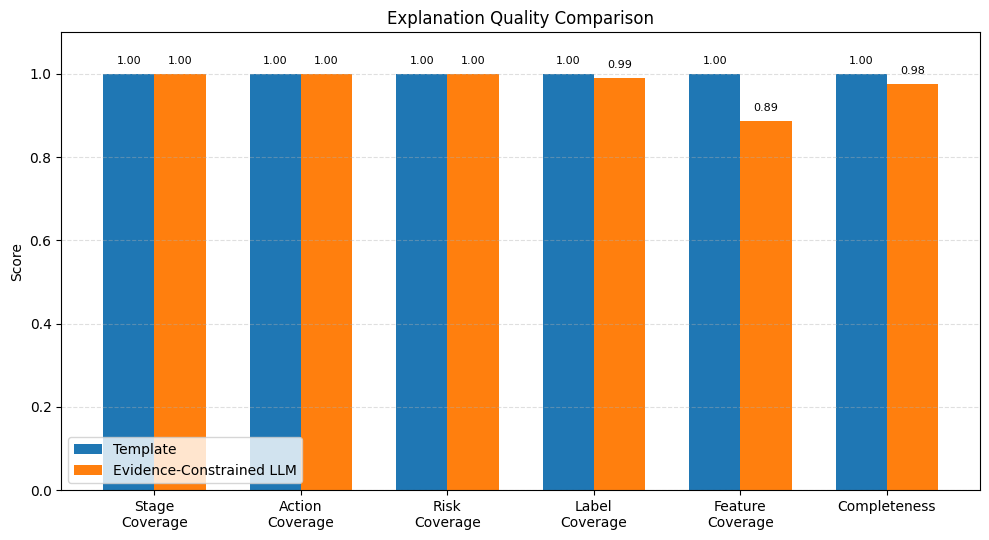

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/fig_explanation_quality_comparison_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/fig_explanation_quality_comparison_300.pdf


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = comparison_v2[
    comparison_v2["metric"].isin([
        "stage_covered",
        "action_covered",
        "risk_covered",
        "label_covered",
        "feature_coverage",
        "completeness_score"
    ])
].copy()

label_map = {
    "stage_covered": "Stage\nCoverage",
    "action_covered": "Action\nCoverage",
    "risk_covered": "Risk\nCoverage",
    "label_covered": "Label\nCoverage",
    "feature_coverage": "Feature\nCoverage",
    "completeness_score": "Completeness"
}

plot_df["metric_label"] = plot_df["metric"].map(label_map)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 5.5))

bars1 = plt.bar(x - width/2, plot_df["template"], width, label="Template")
bars2 = plt.bar(x + width/2, plot_df["llm"], width, label="Evidence-Constrained LLM")

plt.xticks(x, plot_df["metric_label"])
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Explanation Quality Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

png_path = f"{OUTPUT_DIR}/fig_explanation_quality_comparison_300.png"
pdf_path = f"{OUTPUT_DIR}/fig_explanation_quality_comparison_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"
FIG_DIR = f"{OUTPUT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Main 300-sample LLM explanation result
evidence_df = pd.read_csv(f"{OUTPUT_DIR}/xir_llm_explanations_300.csv")

print("Loaded evidence_df:", evidence_df.shape)
print(evidence_df.columns)

# Optional hallucination report
hallucination_path = f"{OUTPUT_DIR}/llm_hallucination_analysis_300.csv"

if os.path.exists(hallucination_path):
    hallucination_df = pd.read_csv(hallucination_path)
    print("Loaded hallucination_df:", hallucination_df.shape)
else:
    hallucination_df = None
    print("Hallucination file not found. Run hallucination analysis first if needed.")

# Basic check
print("Blank LLM explanations:",
      (evidence_df["llm_explanation"].astype(str).str.strip() == "").sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded evidence_df: (300, 13)
Index(['event_id', 'source_dataset', 'true_label', 'predicted_label',
       'attack_stage', 'prediction_confidence', 'risk_score',
       'recommended_action', 'top_xai_features', 'evidence_json',
       'template_explanation', 'llm_prompt', 'llm_explanation'],
      dtype='object')
Loaded hallucination_df: (300, 7)
Blank LLM explanations: 0


# ***Figure 1: Attack-Stage Distribution***

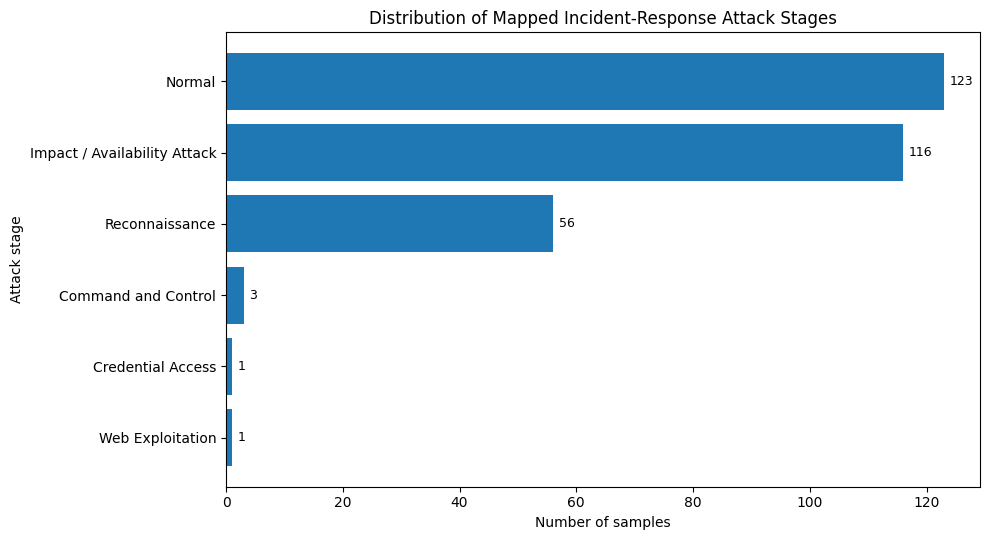

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_attack_stage_distribution_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_attack_stage_distribution_300.pdf


In [ ]:
stage_counts = evidence_df["attack_stage"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 5.5))
plt.barh(stage_counts.index, stage_counts.values)

plt.xlabel("Number of samples")
plt.ylabel("Attack stage")
plt.title("Distribution of Mapped Incident-Response Attack Stages")

for i, v in enumerate(stage_counts.values):
    plt.text(v + 1, i, str(v), va="center", fontsize=9)

plt.tight_layout()

png_path = f"{FIG_DIR}/fig_attack_stage_distribution_300.png"
pdf_path = f"{FIG_DIR}/fig_attack_stage_distribution_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

# ***Figure 2: Recommended Action Distribution***

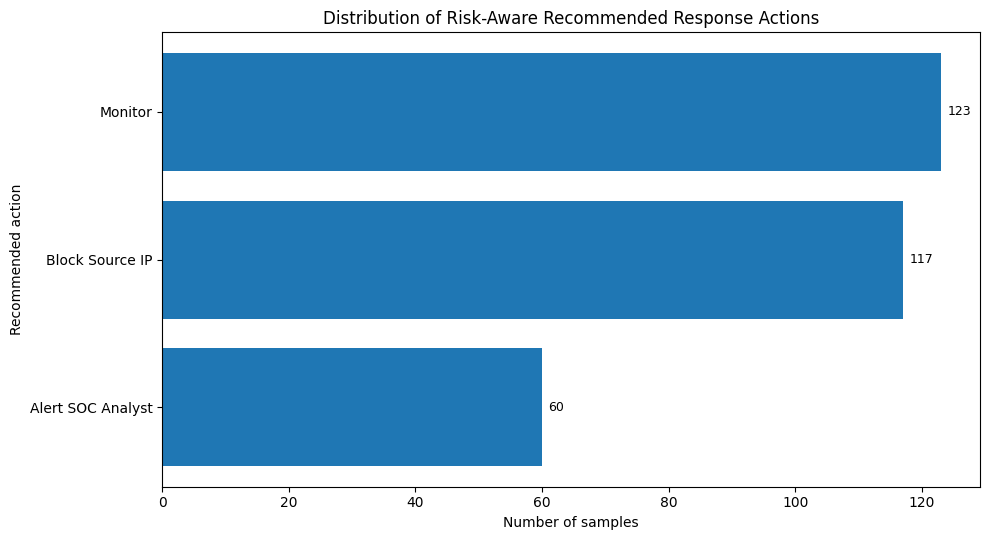

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_recommended_action_distribution_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_recommended_action_distribution_300.pdf


In [ ]:
action_counts = evidence_df["recommended_action"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 5.5))
plt.barh(action_counts.index, action_counts.values)

plt.xlabel("Number of samples")
plt.ylabel("Recommended action")
plt.title("Distribution of Risk-Aware Recommended Response Actions")

for i, v in enumerate(action_counts.values):
    plt.text(v + 1, i, str(v), va="center", fontsize=9)

plt.tight_layout()

png_path = f"{FIG_DIR}/fig_recommended_action_distribution_300.png"
pdf_path = f"{FIG_DIR}/fig_recommended_action_distribution_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

# ***Figure 3: Risk Score Distribution***

Risk Zone Summary:
risk_zone
Monitor zone                123
Alert zone                   60
Block zone                  117
Isolation zone                0
Critical escalation zone      0
Name: count, dtype: int64


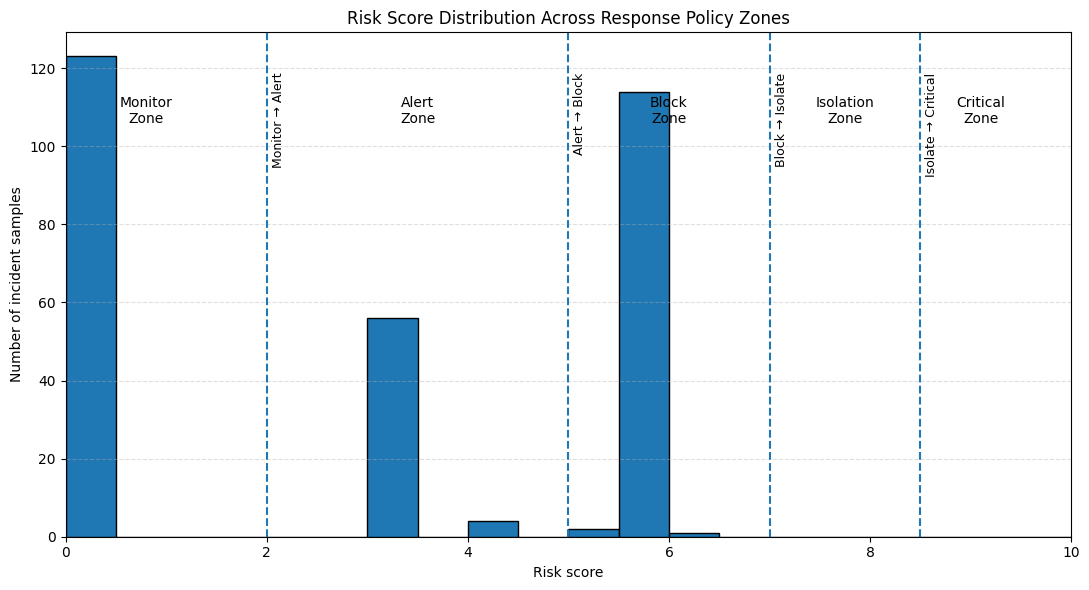

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_risk_score_distribution_policy_zones_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_risk_score_distribution_policy_zones_300.pdf


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

FIG_DIR = f"{OUTPUT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Create risk zones
def assign_risk_zone(risk):
    if risk <= 2:
        return "Monitor zone"
    elif risk <= 5:
        return "Alert zone"
    elif risk <= 7:
        return "Block zone"
    elif risk <= 8.5:
        return "Isolation zone"
    else:
        return "Critical escalation zone"

evidence_df["risk_zone"] = evidence_df["risk_score"].apply(assign_risk_zone)

# Print zone summary
risk_zone_summary = evidence_df["risk_zone"].value_counts().reindex([
    "Monitor zone",
    "Alert zone",
    "Block zone",
    "Isolation zone",
    "Critical escalation zone"
]).fillna(0).astype(int)

print("Risk Zone Summary:")
print(risk_zone_summary)

# Plot improved histogram
plt.figure(figsize=(11, 6))

plt.hist(
    evidence_df["risk_score"],
    bins=np.arange(0, 10.5, 0.5),
    edgecolor="black"
)

# Add policy threshold lines
thresholds = [2, 5, 7, 8.5]
threshold_labels = [
    "Monitor → Alert",
    "Alert → Block",
    "Block → Isolate",
    "Isolate → Critical"
]

for threshold, label in zip(thresholds, threshold_labels):
    plt.axvline(threshold, linestyle="--", linewidth=1.5)
    plt.text(
        threshold + 0.05,
        plt.ylim()[1] * 0.92,
        label,
        rotation=90,
        va="top",
        fontsize=9
    )

# Add zone labels
plt.text(0.8, plt.ylim()[1] * 0.82, "Monitor\nZone", ha="center", fontsize=10)
plt.text(3.5, plt.ylim()[1] * 0.82, "Alert\nZone", ha="center", fontsize=10)
plt.text(6.0, plt.ylim()[1] * 0.82, "Block\nZone", ha="center", fontsize=10)
plt.text(7.75, plt.ylim()[1] * 0.82, "Isolation\nZone", ha="center", fontsize=10)
plt.text(9.1, plt.ylim()[1] * 0.82, "Critical\nZone", ha="center", fontsize=10)

plt.xlabel("Risk score")
plt.ylabel("Number of incident samples")
plt.title("Risk Score Distribution Across Response Policy Zones")
plt.xlim(0, 10)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

png_path = f"{FIG_DIR}/fig_risk_score_distribution_policy_zones_300.png"
pdf_path = f"{FIG_DIR}/fig_risk_score_distribution_policy_zones_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

In [ ]:
risk_zone_table = risk_zone_summary.reset_index()
risk_zone_table.columns = ["risk_zone", "sample_count"]

risk_zone_table["percentage"] = (
    risk_zone_table["sample_count"] / risk_zone_table["sample_count"].sum() * 100
).round(2)

risk_zone_table_path = f"{OUTPUT_DIR}/risk_zone_summary_300.csv"
risk_zone_table.to_csv(risk_zone_table_path, index=False)

print("Saved risk zone table:")
print(risk_zone_table_path)

risk_zone_table

Saved risk zone table:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/risk_zone_summary_300.csv


,risk_zone,sample_count,percentage
0,Monitor zone,123,41.0
1,Alert zone,60,20.0
2,Block zone,117,39.0
3,Isolation zone,0,0.0
4,Critical escalation zone,0,0.0


# ***Figure 4: Confidence vs Risk Score by Recommended Action***

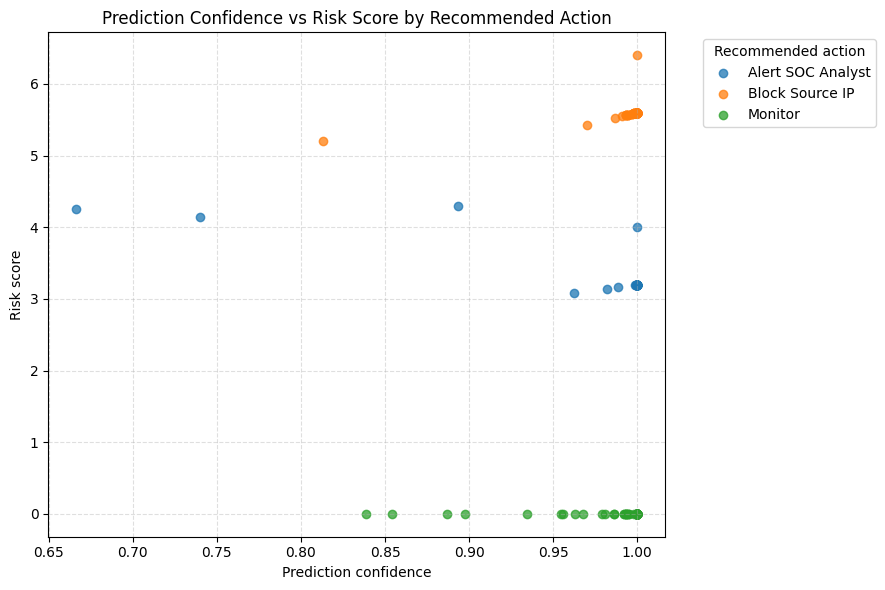

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_confidence_vs_risk_by_action_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_confidence_vs_risk_by_action_300.pdf


In [ ]:
plt.figure(figsize=(9, 6))

for action, group in evidence_df.groupby("recommended_action"):
    plt.scatter(
        group["prediction_confidence"],
        group["risk_score"],
        label=action,
        alpha=0.75
    )

plt.xlabel("Prediction confidence")
plt.ylabel("Risk score")
plt.title("Prediction Confidence vs Risk Score by Recommended Action")
plt.legend(title="Recommended action", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

png_path = f"{FIG_DIR}/fig_confidence_vs_risk_by_action_300.png"
pdf_path = f"{FIG_DIR}/fig_confidence_vs_risk_by_action_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

# ***Figure 5: Global Feature Importance Analysis***

In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"
FIG_DIR = f"{OUTPUT_DIR}/figures"
ARTIFACT_DIR = f"{OUTPUT_DIR}/artifacts"

os.makedirs(FIG_DIR, exist_ok=True)

# Load saved model artifacts
rf_model = joblib.load(f"{ARTIFACT_DIR}/rf_model.pkl")
feature_columns = joblib.load(f"{ARTIFACT_DIR}/feature_columns.pkl")

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

# Save full feature importance table
feature_importance_path = f"{OUTPUT_DIR}/global_feature_importance.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)

print("Saved feature importance table:")
print(feature_importance_path)

feature_importance_df.head(20)

Saved feature importance table:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/global_feature_importance.csv


,feature,importance
0,Destination Port,0.068590
67,Init_Win_bytes_backward,0.055010
16,Flow IAT Mean,0.026613
37,Bwd Packets/s,0.026438
15,Flow Packets/s,0.026169
69,min_seg_size_forward,0.025641
18,Flow IAT Max,0.025028
6,Fwd Packet Length Max,0.024120
17,Flow IAT Std,0.023535
66,Init_Win_bytes_forward,0.023482


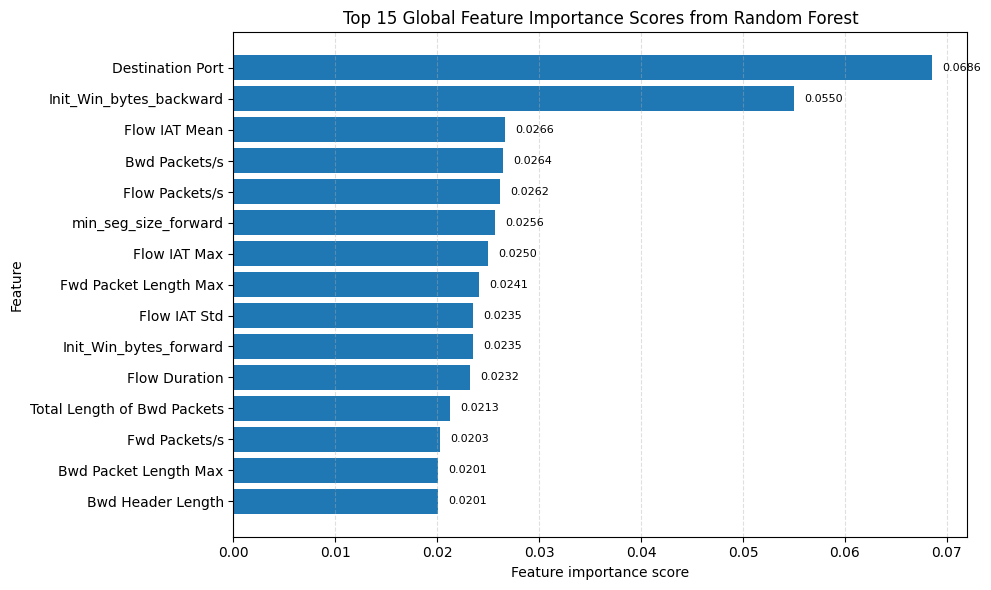

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_global_feature_importance_top15.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_global_feature_importance_top15.pdf


In [ ]:
top_n = 15

top_features = feature_importance_df.head(top_n).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature importance score")
plt.ylabel("Feature")
plt.title("Top 15 Global Feature Importance Scores from Random Forest")

for i, v in enumerate(top_features["importance"]):
    plt.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

png_path = f"{FIG_DIR}/fig_global_feature_importance_top15.png"
pdf_path = f"{FIG_DIR}/fig_global_feature_importance_top15.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

# ***Figure 6: LLM Explanation Length Distribution***

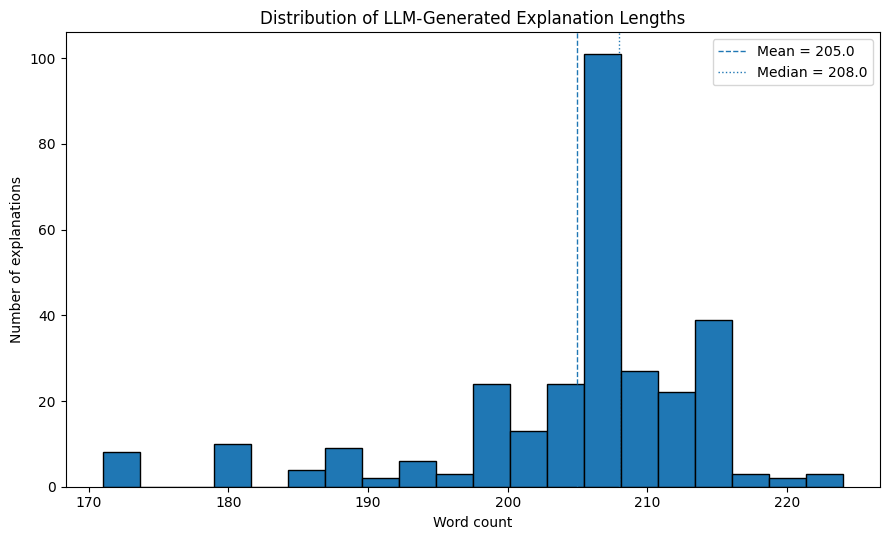

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_llm_explanation_length_distribution_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_llm_explanation_length_distribution_300.pdf


In [ ]:
evidence_df["llm_word_count"] = evidence_df["llm_explanation"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(9, 5.5))
plt.hist(evidence_df["llm_word_count"], bins=20, edgecolor="black")

mean_wc = evidence_df["llm_word_count"].mean()
median_wc = evidence_df["llm_word_count"].median()

plt.axvline(mean_wc, linestyle="--", linewidth=1, label=f"Mean = {mean_wc:.1f}")
plt.axvline(median_wc, linestyle=":", linewidth=1, label=f"Median = {median_wc:.1f}")

plt.xlabel("Word count")
plt.ylabel("Number of explanations")
plt.title("Distribution of LLM-Generated Explanation Lengths")
plt.legend()
plt.tight_layout()

png_path = f"{FIG_DIR}/fig_llm_explanation_length_distribution_300.png"
pdf_path = f"{FIG_DIR}/fig_llm_explanation_length_distribution_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

# ***Figure 7: Hallucination Analysis***

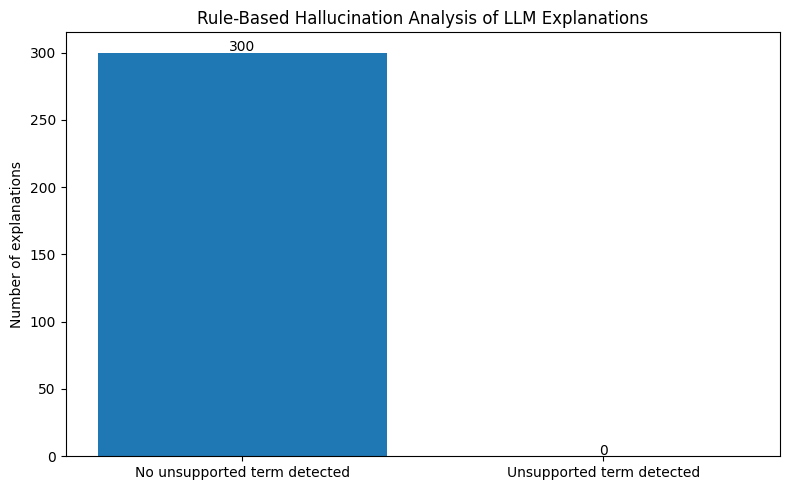

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_hallucination_analysis_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_hallucination_analysis_300.pdf
Hallucination rate: 0.0


In [ ]:
if hallucination_df is None:
    hallucination_df = pd.read_csv(f"{OUTPUT_DIR}/llm_hallucination_analysis_300.csv")

# Count supported vs flagged
flag_count = hallucination_df["hallucination_flag"].sum()
safe_count = len(hallucination_df) - flag_count

hallucination_summary = pd.DataFrame({
    "category": ["No unsupported term detected", "Unsupported term detected"],
    "count": [safe_count, flag_count]
})

plt.figure(figsize=(8, 5))
plt.bar(hallucination_summary["category"], hallucination_summary["count"])

plt.ylabel("Number of explanations")
plt.title("Rule-Based Hallucination Analysis of LLM Explanations")

for i, v in enumerate(hallucination_summary["count"]):
    plt.text(i, v + 1, str(v), ha="center", fontsize=10)

plt.tight_layout()

png_path = f"{FIG_DIR}/fig_hallucination_analysis_300.png"
pdf_path = f"{FIG_DIR}/fig_hallucination_analysis_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

print("Hallucination rate:", flag_count / len(hallucination_df))

In [ ]:
import os

figure_files = sorted([f for f in os.listdir(FIG_DIR) if f.endswith(".png") or f.endswith(".pdf")])

print("Total figure files:", len(figure_files))
for f in figure_files:
    print(f)

Total figure files: 14
fig_attack_stage_distribution_300.pdf
fig_attack_stage_distribution_300.png
fig_confidence_vs_risk_by_action_300.pdf
fig_confidence_vs_risk_by_action_300.png
fig_hallucination_analysis_300.pdf
fig_hallucination_analysis_300.png
fig_llm_explanation_length_distribution_300.pdf
fig_llm_explanation_length_distribution_300.png
fig_recommended_action_distribution_300.pdf
fig_recommended_action_distribution_300.png
fig_risk_score_distribution_300.pdf
fig_risk_score_distribution_300.png
fig_top_feature_evidence_frequency_300.pdf
fig_top_feature_evidence_frequency_300.png


# ***Raw IDS Confusion Matrix on Evidence Samples***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"
FIG_DIR = f"{OUTPUT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

evidence_df = pd.read_csv(f"{OUTPUT_DIR}/xir_llm_explanations_300.csv")

true_labels = evidence_df["true_label"].astype(str)
pred_labels = evidence_df["predicted_label"].astype(str)

labels = sorted(list(set(true_labels) | set(pred_labels)))

cm = confusion_matrix(true_labels, pred_labels, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Save confusion matrix table
raw_cm_path = f"{OUTPUT_DIR}/raw_ids_confusion_matrix_300.csv"
cm_df.to_csv(raw_cm_path)

print("Saved raw IDS confusion matrix:")
print(raw_cm_path)

cm_df

Saved raw IDS confusion matrix:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/raw_ids_confusion_matrix_300.csv


,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS slowloris,PortScan,SSH-Patator,Web Attack � Brute Force
BENIGN,123,0,0,0,0,0,0,0,0
Bot,0,3,0,0,0,0,0,0,0
DDoS,0,0,72,0,0,0,0,0,0
DoS GoldenEye,0,0,0,1,0,0,0,0,0
DoS Hulk,0,0,0,0,40,0,0,0,0
DoS slowloris,0,0,0,0,0,3,0,0,0
PortScan,0,0,0,0,0,0,56,0,0
SSH-Patator,0,0,0,0,0,0,0,1,0
Web Attack � Brute Force,0,0,0,0,0,0,0,0,1


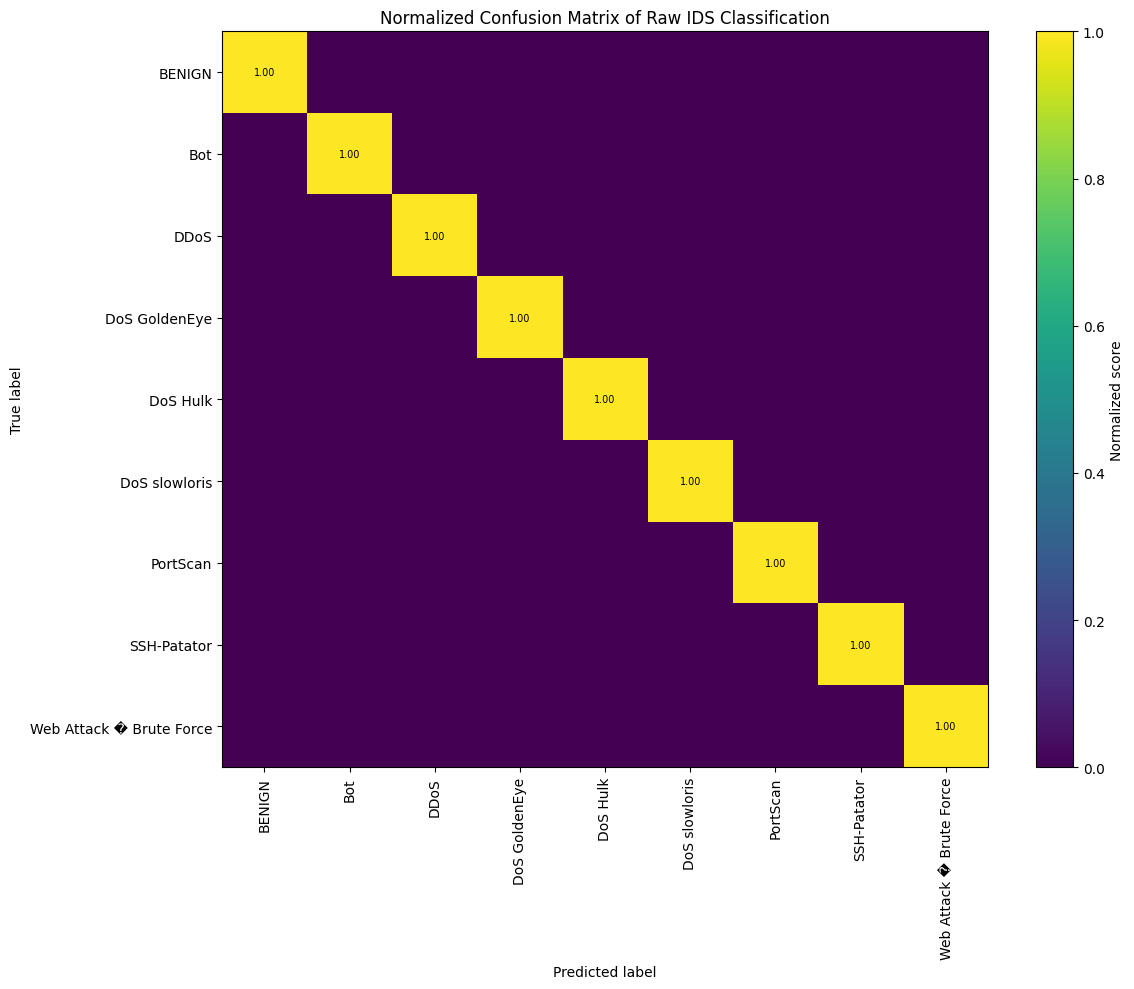

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_raw_ids_confusion_matrix_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_raw_ids_confusion_matrix_300.pdf


In [ ]:
# Normalize by row
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(12, 10))
plt.imshow(cm_normalized, interpolation="nearest", aspect="auto")

plt.title("Normalized Confusion Matrix of Raw IDS Classification")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)

plt.colorbar(label="Normalized score")

# Add values inside cells
for i in range(len(labels)):
    for j in range(len(labels)):
        value = cm_normalized[i, j]
        if value > 0:
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()

png_path = f"{FIG_DIR}/fig_raw_ids_confusion_matrix_300.png"
pdf_path = f"{FIG_DIR}/fig_raw_ids_confusion_matrix_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

# ***Attack-Stage Confusion Matrix***

In [ ]:
def map_attack_stage(label):
    label = str(label).lower()

    if "benign" in label:
        return "Normal"
    elif "portscan" in label:
        return "Reconnaissance"
    elif "ftp" in label or "ssh" in label or "patator" in label:
        return "Credential Access"
    elif "web attack" in label or "xss" in label or "sql" in label or "brute force" in label:
        return "Web Exploitation"
    elif "dos" in label or "ddos" in label:
        return "Impact / Availability Attack"
    elif "bot" in label:
        return "Command and Control"
    elif "infiltration" in label:
        return "Advanced Intrusion"
    elif "heartbleed" in label:
        return "Exploitation / Credential Risk"
    else:
        return "Unknown"


evidence_df["true_attack_stage"] = evidence_df["true_label"].apply(map_attack_stage)
evidence_df["predicted_attack_stage"] = evidence_df["predicted_label"].apply(map_attack_stage)

true_stages = evidence_df["true_attack_stage"]
pred_stages = evidence_df["predicted_attack_stage"]

stage_labels = sorted(list(set(true_stages) | set(pred_stages)))

stage_cm = confusion_matrix(true_stages, pred_stages, labels=stage_labels)

stage_cm_df = pd.DataFrame(stage_cm, index=stage_labels, columns=stage_labels)

# Save table
stage_cm_path = f"{OUTPUT_DIR}/attack_stage_confusion_matrix_300.csv"
stage_cm_df.to_csv(stage_cm_path)

print("Saved attack-stage confusion matrix:")
print(stage_cm_path)

stage_cm_df

Saved attack-stage confusion matrix:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/attack_stage_confusion_matrix_300.csv


,Command and Control,Credential Access,Impact / Availability Attack,Normal,Reconnaissance,Web Exploitation
Command and Control,3,0,0,0,0,0
Credential Access,0,1,0,0,0,0
Impact / Availability Attack,0,0,116,0,0,0
Normal,0,0,0,123,0,0
Reconnaissance,0,0,0,0,56,0
Web Exploitation,0,0,0,0,0,1


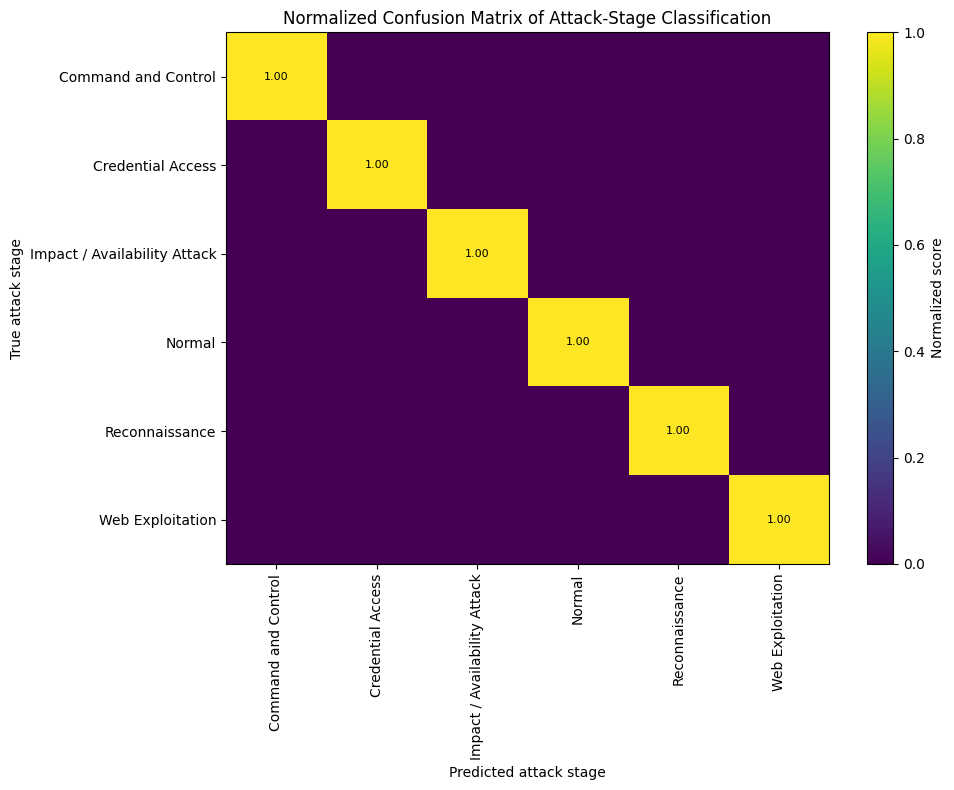

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_attack_stage_confusion_matrix_300.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_attack_stage_confusion_matrix_300.pdf


In [ ]:
stage_cm_normalized = stage_cm.astype(float) / stage_cm.sum(axis=1, keepdims=True)
stage_cm_normalized = np.nan_to_num(stage_cm_normalized)

plt.figure(figsize=(10, 8))
plt.imshow(stage_cm_normalized, interpolation="nearest", aspect="auto")

plt.title("Normalized Confusion Matrix of Attack-Stage Classification")
plt.xlabel("Predicted attack stage")
plt.ylabel("True attack stage")

plt.xticks(np.arange(len(stage_labels)), stage_labels, rotation=90)
plt.yticks(np.arange(len(stage_labels)), stage_labels)

plt.colorbar(label="Normalized score")

for i in range(len(stage_labels)):
    for j in range(len(stage_labels)):
        value = stage_cm_normalized[i, j]
        if value > 0:
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()

png_path = f"{FIG_DIR}/fig_attack_stage_confusion_matrix_300.png"
pdf_path = f"{FIG_DIR}/fig_attack_stage_confusion_matrix_300.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

# ***Combined Classification Summary Table***

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Raw label metrics
raw_acc = accuracy_score(true_labels, pred_labels)
raw_precision, raw_recall, raw_f1, _ = precision_recall_fscore_support(
    true_labels,
    pred_labels,
    average="macro",
    zero_division=0
)

raw_w_precision, raw_w_recall, raw_w_f1, _ = precision_recall_fscore_support(
    true_labels,
    pred_labels,
    average="weighted",
    zero_division=0
)

# Stage metrics
stage_acc = accuracy_score(true_stages, pred_stages)
stage_precision, stage_recall, stage_f1, _ = precision_recall_fscore_support(
    true_stages,
    pred_stages,
    average="macro",
    zero_division=0
)

stage_w_precision, stage_w_recall, stage_w_f1, _ = precision_recall_fscore_support(
    true_stages,
    pred_stages,
    average="weighted",
    zero_division=0
)

summary_df = pd.DataFrame({
    "Task": ["Raw IDS Label Classification", "Attack-Stage Classification"],
    "Accuracy": [raw_acc, stage_acc],
    "Macro Precision": [raw_precision, stage_precision],
    "Macro Recall": [raw_recall, stage_recall],
    "Macro F1": [raw_f1, stage_f1],
    "Weighted Precision": [raw_w_precision, stage_w_precision],
    "Weighted Recall": [raw_w_recall, stage_w_recall],
    "Weighted F1": [raw_w_f1, stage_w_f1]
})

summary_df = summary_df.round(4)

summary_path = f"{OUTPUT_DIR}/classification_summary_300.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved classification summary:")
print(summary_path)

summary_df

Saved classification summary:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/classification_summary_300.csv


,Task,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Raw IDS Label Classification,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Attack-Stage Classification,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"
FIG_DIR = f"{OUTPUT_DIR}/figures"
ARTIFACT_DIR = f"{OUTPUT_DIR}/artifacts"

DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/MachineLearningCVE")

os.makedirs(FIG_DIR, exist_ok=True)

rf_model = joblib.load(f"{ARTIFACT_DIR}/rf_model.pkl")
label_encoder = joblib.load(f"{ARTIFACT_DIR}/label_encoder.pkl")
feature_columns = joblib.load(f"{ARTIFACT_DIR}/feature_columns.pkl")

print("Loaded model and label encoder.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded model and label encoder.


In [ ]:
csv_files = sorted(DATA_DIR.rglob("*.csv"))

dfs = []

for file in csv_files:
    print("Loading:", file.name)
    temp = pd.read_csv(file, low_memory=False)
    temp.columns = temp.columns.str.strip()

    # Same sampling rule used in your original notebook
    if len(temp) > 50000:
        temp = temp.sample(n=50000, random_state=42)

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.columns = df.columns.str.strip()
df["Label"] = df["Label"].astype(str).str.strip()

X = df.drop(columns=["Label"])
y = df["Label"]

X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1, how="all")
X = X.fillna(X.median())

lower = X.quantile(0.001)
upper = X.quantile(0.999)
X = X.clip(lower=lower, upper=upper, axis=1)

# Keep exact model feature order
X = X[feature_columns]

y_encoded = label_encoder.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_test:", X_test.shape)

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
X_test: (80000, 78)


In [ ]:
y_pred = rf_model.predict(X_test)

print("Full test accuracy:", accuracy_score(y_test, y_pred))

all_labels = np.arange(len(label_encoder.classes_))

print(
    classification_report(
        y_test,
        y_pred,
        labels=all_labels,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Full test accuracy: 0.995225
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     64593
                       Bot       0.31      0.93      0.46        99
                      DDoS       1.00      1.00      1.00      5701
             DoS GoldenEye       0.99      0.95      0.97       144
                  DoS Hulk       0.99      1.00      0.99      3318
          DoS Slowhttptest       0.96      0.98      0.97        82
             DoS slowloris       0.99      0.99      0.99        81
               FTP-Patator       1.00      0.99      1.00       179
                Heartbleed       0.00      0.00      0.00         0
              Infiltration       0.00      0.00      0.00         1
                  PortScan       0.99      1.00      1.00      5539
               SSH-Patator       1.00      0.98      0.99       133
  Web Attack � Brute Force       0.73      0.71      0.72        90
Web Attack � Sql I

/tmp/ipykernel_919/601957667.py:17: RuntimeWarning: invalid value encountered in divide
  cm_full_norm = cm_full.astype(float) / cm_full.sum(axis=1, keepdims=True)


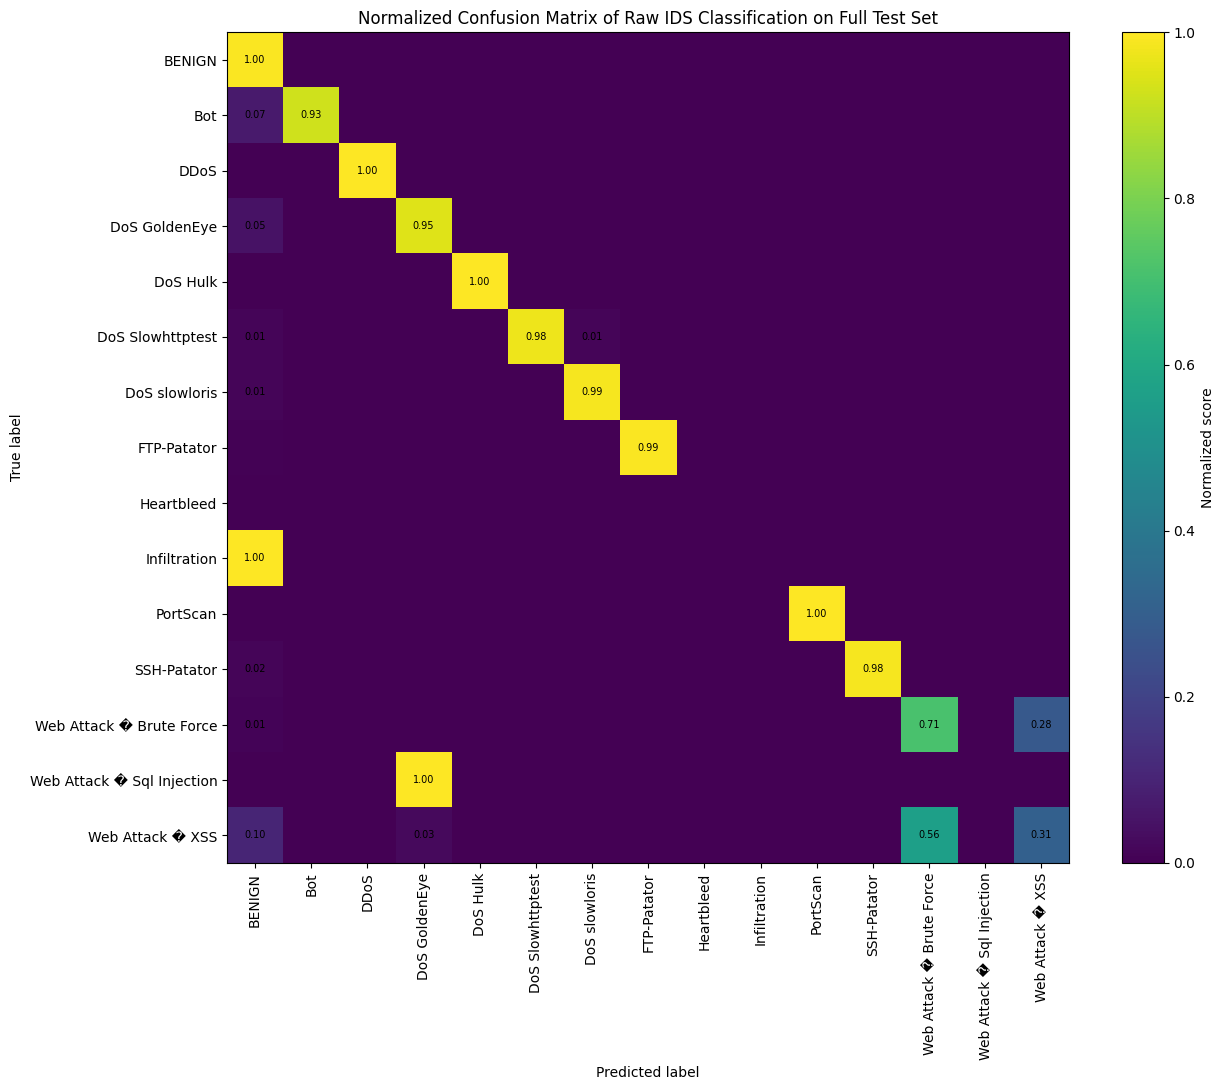

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_raw_ids_confusion_matrix_full_test.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_raw_ids_confusion_matrix_full_test.pdf


In [ ]:
raw_labels = list(label_encoder.classes_)

cm_full = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(raw_labels))
)

cm_full_df = pd.DataFrame(
    cm_full,
    index=raw_labels,
    columns=raw_labels
)

cm_full_df.to_csv(f"{OUTPUT_DIR}/raw_ids_confusion_matrix_full_test_counts.csv")

cm_full_norm = cm_full.astype(float) / cm_full.sum(axis=1, keepdims=True)
cm_full_norm = np.nan_to_num(cm_full_norm)

plt.figure(figsize=(13, 11))
plt.imshow(cm_full_norm, interpolation="nearest", aspect="auto")

plt.title("Normalized Confusion Matrix of Raw IDS Classification on Full Test Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(np.arange(len(raw_labels)), raw_labels, rotation=90)
plt.yticks(np.arange(len(raw_labels)), raw_labels)

plt.colorbar(label="Normalized score")

for i in range(len(raw_labels)):
    for j in range(len(raw_labels)):
        value = cm_full_norm[i, j]
        if value >= 0.01:
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()

png_path = f"{FIG_DIR}/fig_raw_ids_confusion_matrix_full_test.png"
pdf_path = f"{FIG_DIR}/fig_raw_ids_confusion_matrix_full_test.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

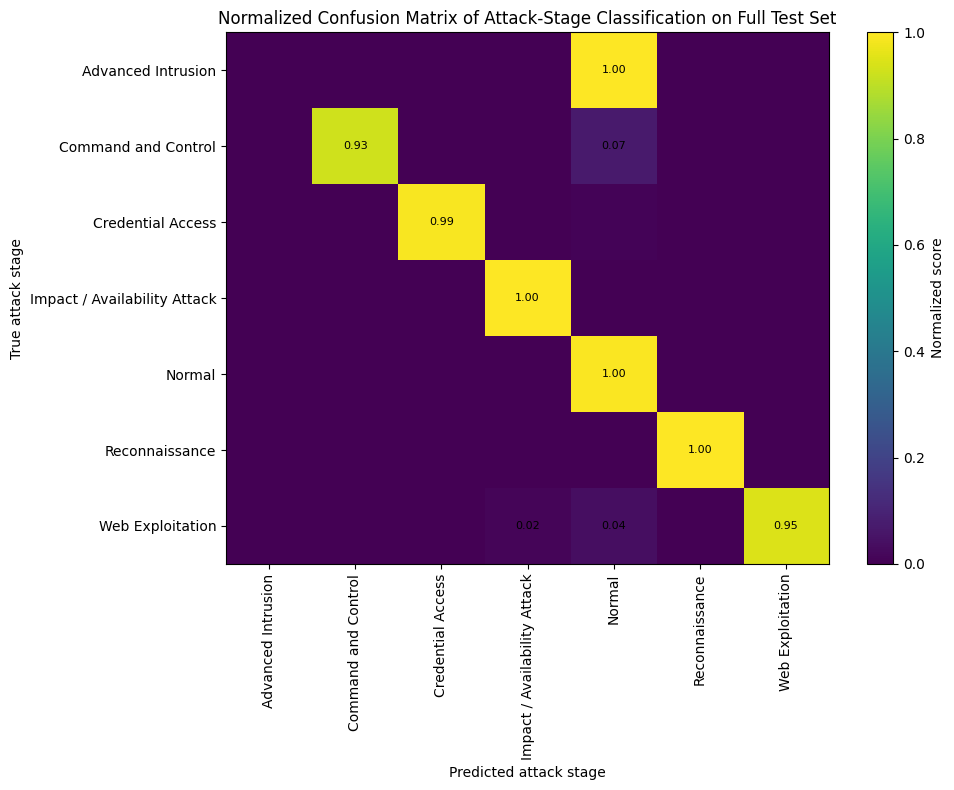

Saved:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_attack_stage_confusion_matrix_full_test.png
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/figures/fig_attack_stage_confusion_matrix_full_test.pdf


In [ ]:
def map_attack_stage(label):
    label = str(label).lower()

    if "benign" in label:
        return "Normal"
    elif "portscan" in label:
        return "Reconnaissance"
    elif "ftp" in label or "ssh" in label or "patator" in label:
        return "Credential Access"
    elif "web attack" in label or "xss" in label or "sql" in label or "brute force" in label:
        return "Web Exploitation"
    elif "dos" in label or "ddos" in label:
        return "Impact / Availability Attack"
    elif "bot" in label:
        return "Command and Control"
    elif "infiltration" in label:
        return "Advanced Intrusion"
    elif "heartbleed" in label:
        return "Exploitation / Credential Risk"
    else:
        return "Unknown"


true_raw_labels = label_encoder.inverse_transform(y_test)
pred_raw_labels = label_encoder.inverse_transform(y_pred)

true_stages = pd.Series(true_raw_labels).apply(map_attack_stage)
pred_stages = pd.Series(pred_raw_labels).apply(map_attack_stage)

stage_labels = sorted(list(set(true_stages) | set(pred_stages)))

stage_cm = confusion_matrix(true_stages, pred_stages, labels=stage_labels)

stage_cm_df = pd.DataFrame(
    stage_cm,
    index=stage_labels,
    columns=stage_labels
)

stage_cm_df.to_csv(f"{OUTPUT_DIR}/attack_stage_confusion_matrix_full_test_counts.csv")

stage_cm_norm = stage_cm.astype(float) / stage_cm.sum(axis=1, keepdims=True)
stage_cm_norm = np.nan_to_num(stage_cm_norm)

plt.figure(figsize=(10, 8))
plt.imshow(stage_cm_norm, interpolation="nearest", aspect="auto")

plt.title("Normalized Confusion Matrix of Attack-Stage Classification on Full Test Set")
plt.xlabel("Predicted attack stage")
plt.ylabel("True attack stage")

plt.xticks(np.arange(len(stage_labels)), stage_labels, rotation=90)
plt.yticks(np.arange(len(stage_labels)), stage_labels)

plt.colorbar(label="Normalized score")

for i in range(len(stage_labels)):
    for j in range(len(stage_labels)):
        value = stage_cm_norm[i, j]
        if value >= 0.01:
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()

png_path = f"{FIG_DIR}/fig_attack_stage_confusion_matrix_full_test.png"
pdf_path = f"{FIG_DIR}/fig_attack_stage_confusion_matrix_full_test.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

In [ ]:
import os
import numpy as np
import pandas as pd

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"

raw_cm_path = f"{OUTPUT_DIR}/raw_ids_confusion_matrix_full_test_counts.csv"
stage_cm_path = f"{OUTPUT_DIR}/attack_stage_confusion_matrix_full_test_counts.csv"

raw_cm_df = pd.read_csv(raw_cm_path, index_col=0)
stage_cm_df = pd.read_csv(stage_cm_path, index_col=0)

def calculate_metrics_from_confusion_matrix(cm_df, task_name):
    cm = cm_df.values.astype(float)

    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    tp = np.diag(cm)

    precision = np.divide(
        tp,
        predicted,
        out=np.zeros_like(tp, dtype=float),
        where=predicted != 0
    )

    recall = np.divide(
        tp,
        support,
        out=np.zeros_like(tp, dtype=float),
        where=support != 0
    )

    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp, dtype=float),
        where=(precision + recall) != 0
    )

    total = cm.sum()
    accuracy = tp.sum() / total if total != 0 else 0

    macro_precision = precision.mean()
    macro_recall = recall.mean()
    macro_f1 = f1.mean()

    weighted_precision = np.average(precision, weights=support) if support.sum() != 0 else 0
    weighted_recall = np.average(recall, weights=support) if support.sum() != 0 else 0
    weighted_f1 = np.average(f1, weights=support) if support.sum() != 0 else 0

    return {
        "Task": task_name,
        "Samples": int(total),
        "Classes": len(cm_df.index),
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted Precision": weighted_precision,
        "Weighted Recall": weighted_recall,
        "Weighted F1": weighted_f1
    }

classification_summary = pd.DataFrame([
    calculate_metrics_from_confusion_matrix(raw_cm_df, "Raw IDS Label Classification"),
    calculate_metrics_from_confusion_matrix(stage_cm_df, "Attack-Stage Classification")
])

classification_summary_rounded = classification_summary.copy()

metric_cols = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1"
]

classification_summary_rounded[metric_cols] = classification_summary_rounded[metric_cols].round(4)

classification_summary_path = f"{OUTPUT_DIR}/table_classification_performance_summary.csv"
classification_summary_rounded.to_csv(classification_summary_path, index=False)

print("Saved classification performance table:")
print(classification_summary_path)

classification_summary_rounded

Saved classification performance table:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/table_classification_performance_summary.csv


,Task,Samples,Classes,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Raw IDS Label Classification,80000,15,0.9952,0.6843,0.7224,0.6928,0.9969,0.9952,0.9959
1,Attack-Stage Classification,80000,7,0.9958,0.7528,0.8370,0.7723,0.9976,0.9958,0.9965


In [ ]:
import os
import pandas as pd
import numpy as np

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results"

template_eval_path = f"{OUTPUT_DIR}/template_eval_v2_300.csv"
llm_eval_path = f"{OUTPUT_DIR}/llm_eval_v2_300.csv"
hallucination_path = f"{OUTPUT_DIR}/llm_hallucination_analysis_300.csv"

template_eval = pd.read_csv(template_eval_path)
llm_eval = pd.read_csv(llm_eval_path)

metric_order = [
    "stage_covered",
    "action_covered",
    "risk_covered",
    "label_covered",
    "feature_coverage",
    "completeness_score",
    "word_count"
]

metric_names = {
    "stage_covered": "Stage Coverage",
    "action_covered": "Action Coverage",
    "risk_covered": "Risk Coverage",
    "label_covered": "Label Coverage",
    "feature_coverage": "Feature Coverage",
    "completeness_score": "Completeness Score",
    "word_count": "Average Word Count"
}

rows = []

for metric in metric_order:
    template_mean = template_eval[metric].mean()
    llm_mean = llm_eval[metric].mean()

    rows.append({
        "Metric": metric_names[metric],
        "Template": template_mean,
        "Evidence-Constrained LLM": llm_mean,
        "Difference": llm_mean - template_mean
    })

explanation_summary = pd.DataFrame(rows)

# Add hallucination row if file exists
if os.path.exists(hallucination_path):
    hallucination_df = pd.read_csv(hallucination_path)
    hallucination_rate = hallucination_df["hallucination_flag"].mean()

    explanation_summary = pd.concat([
        explanation_summary,
        pd.DataFrame([{
            "Metric": "Rule-Based Hallucination Rate",
            "Template": np.nan,
            "Evidence-Constrained LLM": hallucination_rate,
            "Difference": np.nan
        }])
    ], ignore_index=True)

# Round values
explanation_summary_rounded = explanation_summary.copy()
for col in ["Template", "Evidence-Constrained LLM", "Difference"]:
    explanation_summary_rounded[col] = explanation_summary_rounded[col].round(4)

explanation_summary_path = f"{OUTPUT_DIR}/table_explanation_evaluation_summary.csv"
explanation_summary_rounded.to_csv(explanation_summary_path, index=False)

print("Saved explanation evaluation table:")
print(explanation_summary_path)

explanation_summary_rounded

Saved explanation evaluation table:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/table_explanation_evaluation_summary.csv


,Metric,Template,Evidence-Constrained LLM,Difference
0,Stage Coverage,1.0000,1.0000,0.0000
1,Action Coverage,1.0000,1.0000,0.0000
2,Risk Coverage,1.0000,1.0000,0.0000
3,Label Coverage,1.0000,0.9900,-0.0100
4,Feature Coverage,1.0000,0.8867,-0.1133
5,Completeness Score,1.0000,0.9753,-0.0247
6,Average Word Count,100.5267,204.9533,104.4267
7,Rule-Based Hallucination Rate,NaN,0.0000,NaN


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "CIC-IDS-2017/results/artifacts"
)

OUTPUT_DIR = os.path.join(
    BASE_PATH,
    "calibration_analysis"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load the exact verified experiment split
# ------------------------------------------------------------

feature_names = list(
    joblib.load(
        os.path.join(BASE_PATH, "feature_columns.pkl")
    )
)

X_train = pd.read_csv(
    os.path.join(BASE_PATH, "X_train_sample.csv")
)[feature_names]

X_test = pd.read_csv(
    os.path.join(BASE_PATH, "X_test_sample.csv")
)[feature_names]

y_train = np.load(
    os.path.join(BASE_PATH, "y_train.npy"),
    allow_pickle=True
).astype(int)

y_test = np.load(
    os.path.join(BASE_PATH, "y_test.npy"),
    allow_pickle=True
).astype(int)

assert len(X_train) == len(y_train), (
    f"Training mismatch: {len(X_train)} rows versus "
    f"{len(y_train)} labels."
)

assert len(X_test) == len(y_test), (
    f"Test mismatch: {len(X_test)} rows versus "
    f"{len(y_test)} labels."
)

print("Exact verified split loaded.")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# ------------------------------------------------------------
# Exact Decision Tree configuration from original Table I code
# ------------------------------------------------------------

DT_PARAMS = {
    "max_depth": 20,
    "random_state": 42,
    "class_weight": "balanced"
}

dt_model = DecisionTreeClassifier(**DT_PARAMS)

print("\nTraining original Table I Decision Tree...")
print("Parameters:", DT_PARAMS)

dt_model.fit(X_train, y_train)

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

dt_macro_f1 = f1_score(
    y_test,
    dt_predictions,
    average="macro",
    zero_division=0
)

dt_weighted_f1 = f1_score(
    y_test,
    dt_predictions,
    average="weighted",
    zero_division=0
)

print("\nDecision Tree test performance:")
print(f"Accuracy:     {dt_accuracy:.6f}")
print(f"Macro-F1:    {dt_macro_f1:.6f}")
print(f"Weighted-F1: {dt_weighted_f1:.6f}")

# ------------------------------------------------------------
# Compare with current Table I values
# ------------------------------------------------------------

expected_dt = {
    "Accuracy": 0.9969,
    "Macro_F1": 0.8065,
    "Weighted_F1": 0.9970
}

observed_dt = {
    "Accuracy": dt_accuracy,
    "Macro_F1": dt_macro_f1,
    "Weighted_F1": dt_weighted_f1
}

dt_reproduction_check = pd.DataFrame([
    {
        "Metric": metric,
        "Expected": expected_dt[metric],
        "Observed": observed_dt[metric],
        "Absolute_Difference": abs(
            expected_dt[metric] - observed_dt[metric]
        )
    }
    for metric in expected_dt
])

display(dt_reproduction_check.round(6))

# ------------------------------------------------------------
# Save exact Decision Tree and reproduction results
# ------------------------------------------------------------

DT_MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "decision_tree_table_i_exact.joblib"
)

DT_CHECK_PATH = os.path.join(
    OUTPUT_DIR,
    "dt_exact_reproduction_check.csv"
)

joblib.dump(
    dt_model,
    DT_MODEL_PATH
)

dt_reproduction_check.to_csv(
    DT_CHECK_PATH,
    index=False
)

print("\nSaved exact Decision Tree:")
print(DT_MODEL_PATH)

print("\nSaved reproduction check:")
print(DT_CHECK_PATH)

# ------------------------------------------------------------
# Reproduction decision
# ------------------------------------------------------------

dt_matches_table = (
    abs(dt_accuracy - 0.9969) <= 0.002
    and abs(dt_macro_f1 - 0.8065) <= 0.03
    and abs(dt_weighted_f1 - 0.9970) <= 0.002
)

if dt_matches_table:
    print("\nDecision Tree reproduction check passed.")
else:
    print(
        "\nWARNING: The exact Decision Tree still does not "
        "reproduce Table I closely enough."
    )

Exact verified split loaded.
X_train: (320000, 78)
y_train: (320000,)
X_test: (80000, 78)
y_test: (80000,)

Training original Table I Decision Tree...
Parameters: {'max_depth': 20, 'random_state': 42, 'class_weight': 'balanced'}

Decision Tree test performance:
Accuracy:     0.996875
Macro-F1:    0.806475
Weighted-F1: 0.997028


,Metric,Expected,Observed,Absolute_Difference
0,Accuracy,0.9969,0.996875,0.000025
1,Macro_F1,0.8065,0.806475,0.000025
2,Weighted_F1,0.9970,0.997028,0.000028



Saved exact Decision Tree:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/decision_tree_table_i_exact.joblib

Saved reproduction check:
/content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/dt_exact_reproduction_check.csv

Decision Tree reproduction check passed.


In [5]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    roc_auc_score,
    average_precision_score
)

BASE_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "CIC-IDS-2017/results/artifacts"
)

OUTPUT_DIR = os.path.join(
    BASE_PATH,
    "calibration_analysis"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load exact models
rf_model = joblib.load(
    os.path.join(BASE_PATH, "rf_model.pkl")
)

dt_model = joblib.load(
    os.path.join(
        OUTPUT_DIR,
        "decision_tree_table_i_exact.joblib"
    )
)

feature_names = list(
    joblib.load(
        os.path.join(BASE_PATH, "feature_columns.pkl")
    )
)

label_encoder = joblib.load(
    os.path.join(BASE_PATH, "label_encoder.pkl")
)

# Load verified test set
X_test = pd.read_csv(
    os.path.join(BASE_PATH, "X_test_sample.csv")
)[feature_names]

y_test = np.load(
    os.path.join(BASE_PATH, "y_test.npy"),
    allow_pickle=True
).astype(int)

assert len(X_test) == len(y_test)
assert X_test.shape[1] == rf_model.n_features_in_
assert X_test.shape[1] == dt_model.n_features_in_

print("Exact models and test split loaded.")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Decision Tree parameters:", dt_model.get_params())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Exact models and test split loaded.
X_test: (80000, 78)
y_test: (80000,)
Decision Tree parameters: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [6]:
SHARED_CLASSES = np.asarray(rf_model.classes_)
N_BINS = 15

LOW_CONFIDENCE_THRESHOLD = 0.70
HIGH_CONFIDENCE_THRESHOLD = 0.99


def align_probabilities(
    probabilities,
    source_classes,
    target_classes
):
    """Align predict_proba columns to one shared class order."""

    source_classes = list(source_classes)
    target_classes = list(target_classes)

    aligned = np.zeros(
        (len(probabilities), len(target_classes)),
        dtype=float
    )

    source_lookup = {
        class_id: index
        for index, class_id in enumerate(source_classes)
    }

    for target_index, class_id in enumerate(target_classes):
        if class_id in source_lookup:
            aligned[:, target_index] = probabilities[
                :,
                source_lookup[class_id]
            ]

    row_sums = aligned.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0

    return aligned / row_sums


def multiclass_brier_score(
    y_true,
    probabilities,
    classes
):
    """Mean summed squared error across all classes."""

    class_lookup = {
        class_id: index
        for index, class_id in enumerate(classes)
    }

    one_hot = np.zeros_like(
        probabilities,
        dtype=float
    )

    for row_index, true_class in enumerate(y_true):
        one_hot[
            row_index,
            class_lookup[true_class]
        ] = 1.0

    return float(
        np.mean(
            np.sum(
                (one_hot - probabilities) ** 2,
                axis=1
            )
        )
    )


def top_label_ece(
    y_true,
    probabilities,
    classes,
    n_bins=15
):
    """Top-label expected calibration error."""

    classes = np.asarray(classes)

    confidence = probabilities.max(axis=1)
    predictions = classes[
        probabilities.argmax(axis=1)
    ]

    correct = (
        predictions == np.asarray(y_true)
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0
    maximum_gap = 0.0
    rows = []

    for index in range(n_bins):
        lower = bin_edges[index]
        upper = bin_edges[index + 1]

        if index == 0:
            mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            mask = (
                (confidence > lower)
                & (confidence <= upper)
            )

        count = int(mask.sum())

        if count == 0:
            continue

        mean_confidence = float(
            confidence[mask].mean()
        )

        empirical_accuracy = float(
            correct[mask].mean()
        )

        gap = abs(
            empirical_accuracy - mean_confidence
        )

        sample_fraction = count / len(confidence)

        ece += sample_fraction * gap
        maximum_gap = max(maximum_gap, gap)

        rows.append({
            "Bin": index + 1,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Count": count,
            "Sample_Fraction": sample_fraction,
            "Mean_Confidence": mean_confidence,
            "Empirical_Accuracy": empirical_accuracy,
            "Absolute_Gap": gap
        })

    return (
        float(ece),
        float(maximum_gap),
        pd.DataFrame(rows)
    )


def evaluate_model(
    model_name,
    model,
    X,
    y_true
):
    raw_probabilities = model.predict_proba(X)

    probabilities = align_probabilities(
        raw_probabilities,
        model.classes_,
        SHARED_CLASSES
    )

    predictions = SHARED_CLASSES[
        probabilities.argmax(axis=1)
    ]

    confidence = probabilities.max(axis=1)

    correct = predictions == y_true
    errors = ~correct

    ece, maximum_gap, reliability_bins = top_label_ece(
        y_true,
        probabilities,
        SHARED_CLASSES,
        n_bins=N_BINS
    )

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Macro_F1": f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Weighted_F1": f1_score(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Multiclass_Brier": multiclass_brier_score(
            y_true,
            probabilities,
            SHARED_CLASSES
        ),
        "Log_Loss": log_loss(
            y_true,
            probabilities,
            labels=SHARED_CLASSES
        ),
        "ECE_15_Bins": ece,
        "Maximum_Calibration_Gap": maximum_gap,
        "Mean_Max_Probability": float(
            confidence.mean()
        ),
        "Median_Max_Probability": float(
            np.median(confidence)
        ),
        "Confidence_Std": float(
            confidence.std()
        ),
        "Fraction_Confidence_Above_0.99": float(
            (confidence > 0.99).mean()
        ),
        "Fraction_Confidence_Below_0.70": float(
            (confidence < 0.70).mean()
        ),
        "Number_Routed_Below_0.70": int(
            (confidence < 0.70).sum()
        ),
        "Number_of_Errors": int(errors.sum()),
        "Mean_Confidence_Correct": float(
            confidence[correct].mean()
        ),
        "Mean_Confidence_Errors": (
            float(confidence[errors].mean())
            if errors.any()
            else np.nan
        ),
        "Median_Confidence_Errors": (
            float(np.median(confidence[errors]))
            if errors.any()
            else np.nan
        ),
        "Fraction_Errors_Above_0.99": (
            float((confidence[errors] > 0.99).mean())
            if errors.any()
            else np.nan
        )
    }

    event_details = pd.DataFrame({
        "True_Label_ID": y_true,
        "Predicted_Label_ID": predictions,
        "Correct": correct,
        "Confidence": confidence,
        "Uncertainty": 1.0 - confidence
    })

    return {
        "metrics": metrics,
        "probabilities": probabilities,
        "predictions": predictions,
        "confidence": confidence,
        "correct": correct,
        "errors": errors,
        "reliability_bins": reliability_bins,
        "event_details": event_details
    }


print("Evaluation functions ready.")

Evaluation functions ready.


In [7]:
print("Evaluating exact Decision Tree...")
dt_results = evaluate_model(
    "Decision Tree",
    dt_model,
    X_test,
    y_test
)

print("Evaluating saved Random Forest...")
rf_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)

calibration_table = pd.DataFrame([
    dt_results["metrics"],
    rf_results["metrics"]
]).set_index("Model")

calibration_path = os.path.join(
    OUTPUT_DIR,
    "table_vi_dt_vs_rf_calibration.csv"
)

calibration_table.to_csv(
    calibration_path
)

display(calibration_table.round(6))

print("Saved:", calibration_path)

Evaluating exact Decision Tree...
Evaluating saved Random Forest...


,Accuracy,Macro_F1,Weighted_F1,Multiclass_Brier,Log_Loss,ECE_15_Bins,Maximum_Calibration_Gap,Mean_Max_Probability,Median_Max_Probability,Confidence_Std,Fraction_Confidence_Above_0.99,Fraction_Confidence_Below_0.70,Number_Routed_Below_0.70,Number_of_Errors,Mean_Confidence_Correct,Mean_Confidence_Errors,Median_Confidence_Errors,Fraction_Errors_Above_0.99
Model,,,,,,,,,,,,,,,,,,
Decision Tree,0.996875,0.806475,0.997028,0.005991,0.069549,0.002961,0.34351,0.999836,1.0,0.006861,0.999212,0.000125,10,250,0.999924,0.971744,1.000000,0.89600
Random Forest,0.995225,0.742294,0.995884,0.007575,0.021379,0.005191,0.38627,0.990299,1.0,0.044121,0.900262,0.007862,629,382,0.991774,0.682905,0.638816,0.08377


Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/table_vi_dt_vs_rf_calibration.csv


In [8]:
dt_bins = dt_results["reliability_bins"].copy()
dt_bins.insert(0, "Model", "Decision Tree")

rf_bins = rf_results["reliability_bins"].copy()
rf_bins.insert(0, "Model", "Random Forest")

reliability_data = pd.concat(
    [dt_bins, rf_bins],
    ignore_index=True
)

reliability_path = os.path.join(
    OUTPUT_DIR,
    "reliability_bins_dt_vs_rf.csv"
)

reliability_data.to_csv(
    reliability_path,
    index=False
)

dt_events = dt_results["event_details"].copy()
dt_events.insert(0, "Model", "Decision Tree")

rf_events = rf_results["event_details"].copy()
rf_events.insert(0, "Model", "Random Forest")

event_confidence = pd.concat(
    [dt_events, rf_events],
    ignore_index=True
)

event_confidence["True_Label"] = (
    label_encoder.inverse_transform(
        event_confidence["True_Label_ID"].astype(int)
    )
)

event_confidence["Predicted_Label"] = (
    label_encoder.inverse_transform(
        event_confidence[
            "Predicted_Label_ID"
        ].astype(int)
    )
)

event_path = os.path.join(
    OUTPUT_DIR,
    "dt_vs_rf_event_confidence.csv"
)

event_confidence.to_csv(
    event_path,
    index=False
)

print("Saved:", reliability_path)
print("Saved:", event_path)

Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/reliability_bins_dt_vs_rf.csv
Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/dt_vs_rf_event_confidence.csv


In [9]:
REVIEW_THRESHOLDS = [
    0.70,
    0.80,
    0.90,
    0.95,
    0.99
]


def uncertainty_utility(
    model_name,
    model_result
):
    confidence = np.asarray(
        model_result["confidence"]
    )

    correct = np.asarray(
        model_result["correct"]
    )

    errors = ~correct
    uncertainty = 1.0 - confidence

    number_of_errors = int(errors.sum())
    overall_error_rate = float(errors.mean())

    if errors.any() and correct.any():
        error_auroc = roc_auc_score(
            errors.astype(int),
            uncertainty
        )

        error_auprc = average_precision_score(
            errors.astype(int),
            uncertainty
        )
    else:
        error_auroc = np.nan
        error_auprc = np.nan

    summary = {
        "Model": model_name,
        "Test_Events": len(confidence),
        "Errors": number_of_errors,
        "Overall_Error_Rate": overall_error_rate,
        "Mean_Confidence_Correct": float(
            confidence[correct].mean()
        ),
        "Mean_Confidence_Errors": (
            float(confidence[errors].mean())
            if errors.any()
            else np.nan
        ),
        "Median_Confidence_Errors": (
            float(np.median(confidence[errors]))
            if errors.any()
            else np.nan
        ),
        "Fraction_Errors_Above_0.99": (
            float((confidence[errors] > 0.99).mean())
            if errors.any()
            else np.nan
        ),
        "Error_Detection_AUROC": error_auroc,
        "Error_Detection_AUPRC": error_auprc
    }

    routing_rows = []

    for threshold in REVIEW_THRESHOLDS:
        review_mask = confidence < threshold
        retained_mask = ~review_mask

        reviewed_events = int(review_mask.sum())
        captured_errors = int(
            (review_mask & errors).sum()
        )

        reviewed_error_rate = (
            float(errors[review_mask].mean())
            if reviewed_events > 0
            else np.nan
        )

        error_enrichment = (
            reviewed_error_rate / overall_error_rate
            if reviewed_events > 0
            and overall_error_rate > 0
            else np.nan
        )

        routing_rows.append({
            "Model": model_name,
            "Confidence_Threshold": threshold,
            "Reviewed_Events": reviewed_events,
            "Reviewed_Fraction": (
                reviewed_events / len(confidence)
            ),
            "Captured_Errors": captured_errors,
            "Error_Capture_Rate": (
                captured_errors / number_of_errors
                if number_of_errors > 0
                else np.nan
            ),
            "Error_Rate_Among_Reviewed": (
                reviewed_error_rate
            ),
            "Error_Enrichment": error_enrichment,
            "Retained_Events": int(
                retained_mask.sum()
            ),
            "Retained_Accuracy": (
                float(correct[retained_mask].mean())
                if retained_mask.any()
                else np.nan
            )
        })

    # Risk–coverage curve
    descending_order = np.argsort(-confidence)
    sorted_correct = correct[descending_order]

    coverage = (
        np.arange(1, len(sorted_correct) + 1)
        / len(sorted_correct)
    )

    retained_accuracy = (
        np.cumsum(sorted_correct)
        / np.arange(1, len(sorted_correct) + 1)
    )

    selective_risk = 1.0 - retained_accuracy

    risk_coverage = pd.DataFrame({
        "Model": model_name,
        "Coverage": coverage,
        "Selective_Risk": selective_risk
    })

    return (
        summary,
        pd.DataFrame(routing_rows),
        risk_coverage
    )


dt_summary, dt_routing, dt_risk = uncertainty_utility(
    "Decision Tree",
    dt_results
)

rf_summary, rf_routing, rf_risk = uncertainty_utility(
    "Random Forest",
    rf_results
)

uncertainty_table = pd.DataFrame([
    dt_summary,
    rf_summary
]).set_index("Model")

uncertainty_path = os.path.join(
    OUTPUT_DIR,
    "table_vii_uncertainty_utility_dt_vs_rf.csv"
)

uncertainty_table.to_csv(
    uncertainty_path
)

routing_table = pd.concat(
    [dt_routing, rf_routing],
    ignore_index=True
)

routing_path = os.path.join(
    OUTPUT_DIR,
    "confidence_review_routing_dt_vs_rf.csv"
)

routing_table.to_csv(
    routing_path,
    index=False
)

risk_coverage_data = pd.concat(
    [dt_risk, rf_risk],
    ignore_index=True
)

risk_path = os.path.join(
    OUTPUT_DIR,
    "risk_coverage_dt_vs_rf.csv"
)

risk_coverage_data.to_csv(
    risk_path,
    index=False
)

print("UNCERTAINTY UTILITY")
display(uncertainty_table.round(6))

print("\nCONFIDENCE REVIEW ROUTING")
display(routing_table.round(6))

print("Saved:", uncertainty_path)
print("Saved:", routing_path)
print("Saved:", risk_path)

UNCERTAINTY UTILITY


,Test_Events,Errors,Overall_Error_Rate,Mean_Confidence_Correct,Mean_Confidence_Errors,Median_Confidence_Errors,Fraction_Errors_Above_0.99,Error_Detection_AUROC,Error_Detection_AUPRC
Model,,,,,,,,,
Decision Tree,80000,250,0.003125,0.999924,0.971744,1.000000,0.89600,0.720559,0.152805
Random Forest,80000,382,0.004775,0.991774,0.682905,0.638816,0.08377,0.978889,0.391015



CONFIDENCE REVIEW ROUTING


,Model,Confidence_Threshold,Reviewed_Events,Reviewed_Fraction,Captured_Errors,Error_Capture_Rate,Error_Rate_Among_Reviewed,Error_Enrichment,Retained_Events,Retained_Accuracy
0,Decision Tree,0.70,10,0.000125,6,0.024000,0.600000,192.000000,79990,0.996950
1,Decision Tree,0.80,33,0.000412,20,0.080000,0.606061,193.939394,79967,0.997124
2,Decision Tree,0.90,33,0.000412,20,0.080000,0.606061,193.939394,79967,0.997124
3,Decision Tree,0.95,40,0.000500,23,0.092000,0.575000,184.000000,79960,0.997161
4,Decision Tree,0.99,63,0.000788,26,0.104000,0.412698,132.063492,79937,0.997198
5,Random Forest,0.70,629,0.007862,247,0.646597,0.392687,82.238074,79371,0.998299
6,Random Forest,0.80,965,0.012062,295,0.772251,0.305699,64.020834,79035,0.998899
7,Random Forest,0.90,2115,0.026438,326,0.853403,0.154137,32.280024,77885,0.999281
8,Random Forest,0.95,4264,0.053300,341,0.892670,0.079972,16.748033,75736,0.999459
9,Random Forest,0.99,7979,0.099738,350,0.916230,0.043865,9.186418,72021,0.999556


Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/table_vii_uncertainty_utility_dt_vs_rf.csv
Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/confidence_review_routing_dt_vs_rf.csv
Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/risk_coverage_dt_vs_rf.csv


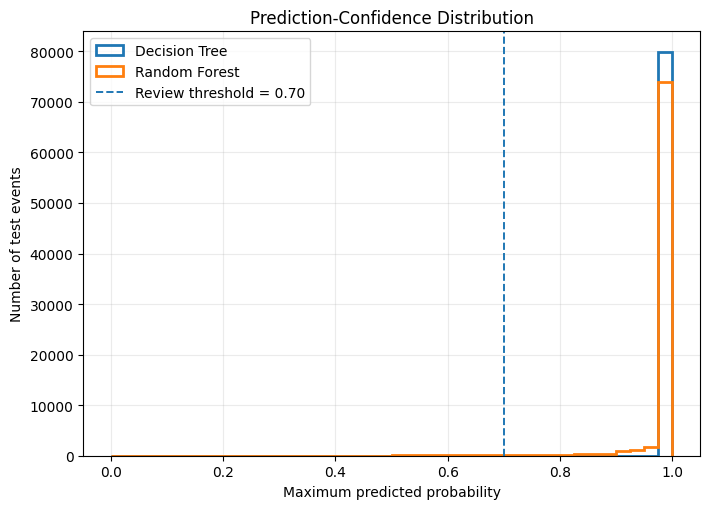

Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/fig_confidence_distribution_dt_vs_rf.png
Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/fig_confidence_distribution_dt_vs_rf.pdf


In [10]:
confidence_bins = np.linspace(
    0.0,
    1.0,
    41
)

plt.figure(figsize=(7.2, 5.2))

plt.hist(
    dt_results["confidence"],
    bins=confidence_bins,
    histtype="step",
    linewidth=2,
    label="Decision Tree"
)

plt.hist(
    rf_results["confidence"],
    bins=confidence_bins,
    histtype="step",
    linewidth=2,
    label="Random Forest"
)

plt.axvline(
    LOW_CONFIDENCE_THRESHOLD,
    linestyle="--",
    linewidth=1.4,
    label="Review threshold = 0.70"
)

plt.xlabel("Maximum predicted probability")
plt.ylabel("Number of test events")
plt.title(
    "Prediction-Confidence Distribution"
)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

confidence_png = os.path.join(
    OUTPUT_DIR,
    "fig_confidence_distribution_dt_vs_rf.png"
)

confidence_pdf = os.path.join(
    OUTPUT_DIR,
    "fig_confidence_distribution_dt_vs_rf.pdf"
)

plt.savefig(
    confidence_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    confidence_pdf,
    bbox_inches="tight"
)

plt.show()

print("Saved:", confidence_png)
print("Saved:", confidence_pdf)

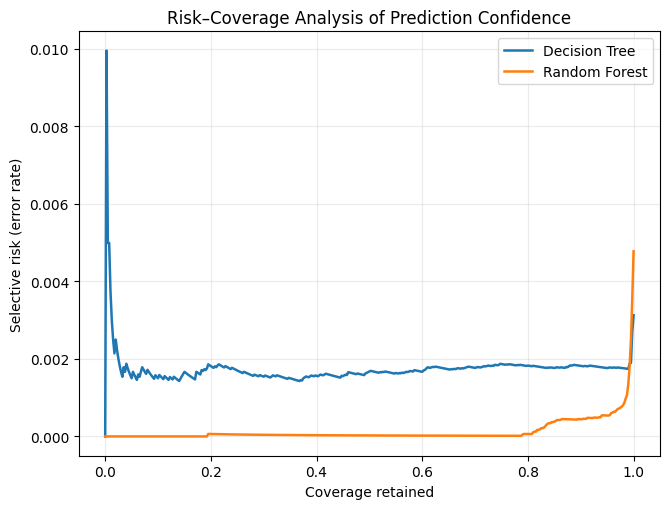

Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/fig_risk_coverage_dt_vs_rf.png
Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/fig_risk_coverage_dt_vs_rf.pdf


In [11]:
plt.figure(figsize=(6.8, 5.2))

for model_name, model_data in [
    ("Decision Tree", dt_risk),
    ("Random Forest", rf_risk)
]:
    plot_data = model_data.iloc[::200].copy()

    if plot_data.iloc[-1]["Coverage"] < 1.0:
        plot_data = pd.concat(
            [plot_data, model_data.tail(1)],
            ignore_index=True
        )

    plt.plot(
        plot_data["Coverage"],
        plot_data["Selective_Risk"],
        linewidth=1.8,
        label=model_name
    )

plt.xlabel("Coverage retained")
plt.ylabel("Selective risk (error rate)")
plt.title(
    "Risk–Coverage Analysis of Prediction Confidence"
)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

risk_png = os.path.join(
    OUTPUT_DIR,
    "fig_risk_coverage_dt_vs_rf.png"
)

risk_pdf = os.path.join(
    OUTPUT_DIR,
    "fig_risk_coverage_dt_vs_rf.pdf"
)

plt.savefig(
    risk_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    risk_pdf,
    bbox_inches="tight"
)

plt.show()

print("Saved:", risk_png)
print("Saved:", risk_pdf)

In [12]:
dt_cal = calibration_table.loc["Decision Tree"]
rf_cal = calibration_table.loc["Random Forest"]

dt_unc = uncertainty_table.loc["Decision Tree"]
rf_unc = uncertainty_table.loc["Random Forest"]

dt_route_070 = dt_routing[
    dt_routing["Confidence_Threshold"] == 0.70
].iloc[0]

rf_route_070 = rf_routing[
    rf_routing["Confidence_Threshold"] == 0.70
].iloc[0]

table_vi = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Accuracy": dt_cal["Accuracy"],
        "Macro_F1": dt_cal["Macro_F1"],
        "Mean_Max_Probability": (
            dt_cal["Mean_Max_Probability"]
        ),
        "Mean_Confidence_Errors": (
            dt_unc["Mean_Confidence_Errors"]
        ),
        "Errors_Above_0.99": (
            dt_unc["Fraction_Errors_Above_0.99"]
        ),
        "Error_Detection_AUROC": (
            dt_unc["Error_Detection_AUROC"]
        ),
        "Error_Detection_AUPRC": (
            dt_unc["Error_Detection_AUPRC"]
        ),
        "Reviewed_Fraction_at_0.70": (
            dt_route_070["Reviewed_Fraction"]
        ),
        "Error_Capture_at_0.70": (
            dt_route_070["Error_Capture_Rate"]
        ),
        "Retained_Accuracy_at_0.70": (
            dt_route_070["Retained_Accuracy"]
        )
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_cal["Accuracy"],
        "Macro_F1": rf_cal["Macro_F1"],
        "Mean_Max_Probability": (
            rf_cal["Mean_Max_Probability"]
        ),
        "Mean_Confidence_Errors": (
            rf_unc["Mean_Confidence_Errors"]
        ),
        "Errors_Above_0.99": (
            rf_unc["Fraction_Errors_Above_0.99"]
        ),
        "Error_Detection_AUROC": (
            rf_unc["Error_Detection_AUROC"]
        ),
        "Error_Detection_AUPRC": (
            rf_unc["Error_Detection_AUPRC"]
        ),
        "Reviewed_Fraction_at_0.70": (
            rf_route_070["Reviewed_Fraction"]
        ),
        "Error_Capture_at_0.70": (
            rf_route_070["Error_Capture_Rate"]
        ),
        "Retained_Accuracy_at_0.70": (
            rf_route_070["Retained_Accuracy"]
        )
    }
])

table_vi_path = os.path.join(
    OUTPUT_DIR,
    "table_vi_classification_uncertainty_utility.csv"
)

table_vi.to_csv(
    table_vi_path,
    index=False
)

display(table_vi.round(6))

print("Saved:", table_vi_path)

,Model,Accuracy,Macro_F1,Mean_Max_Probability,Mean_Confidence_Errors,Errors_Above_0.99,Error_Detection_AUROC,Error_Detection_AUPRC,Reviewed_Fraction_at_0.70,Error_Capture_at_0.70,Retained_Accuracy_at_0.70
0,Decision Tree,0.996875,0.806475,0.999836,0.971744,0.89600,0.720559,0.152805,0.000125,0.024000,0.996950
1,Random Forest,0.995225,0.742294,0.990299,0.682905,0.08377,0.978889,0.391015,0.007862,0.646597,0.998299


Saved: /content/drive/MyDrive/Colab Notebooks/CIC-IDS-2017/results/artifacts/calibration_analysis/table_vi_classification_uncertainty_utility.csv
